# <div dir="rtl"> 🔹שלב 1: הגדרת והפעלת צינור ETL </div>
<div dir="rtl"> בשלב זה אנו מייבאים ומגדירים את כל הספריות הדרושות ואת החיבור למסד הנתונים, מממשים את הפונקציות load_posted_news ו-load_skipped_news כדי לקרוא, להסיר כפילויות ולסנן רשומות חדשות מקובצי JSON אל תוך DataFrames, ובונים את הפונקציה הראשית כדי לכתוב את המאמרים החדשים לטבלאות PostedNews ו-SkippedNews.</div>

#### <div dir="rtl"> חלק 1: ייבוא ספריות וחיבור למסד הנתונים </div>
<div dir="rtl"> ייבוא ספריות מרכזיות לעבודה עם JSON, עיבוד נתונים, גישה למסד נתונים, ויזואליזציה, ניתוח גרפים ו-NLP/למידת מכונה, ולאחר מכן בנייה והפעלה של מנוע SQLAlchemy לצורך חיבור למסד הנתונים CyberNewsBot SQL Server.</div>


In [99]:
# === Standard Library ===
import json                                 # עבודה עם גייסון
import warnings                             # ניהול אזהרות ומניעת הודעות מיותרות

# === Data Manipulation ===
import pandas as pd                         # ספרייה לעבודה עם טבלאות
import numpy as np                          # ספרייה מתמטית

# === Database Connectivity ===
from sqlalchemy import create_engine        # לחיבור אס קיו אל
from sqlalchemy.types import NVARCHAR, Date, Time  
                                            # להגדרת טיפוסים לעבודה עם sql

# === Visualization ===
import matplotlib.pyplot as plt             # Core plotting API ספריית גרפים עיקרית 
import matplotlib.colors as mcolors         # Predefined color palettes and utilities צבעים ומפות צבעים  
import matplotlib.cm as cm                  # Colormap registry and mapping functions צבעים ומפות צבעים
from matplotlib.dates import DateFormatter  # Formatting dates on axis תאריכים בגרפים
import matplotlib.dates as mdates           # Date locators and formatters פורמט תאריכים
from matplotlib.lines import Line2D         # Custom legend handles לבניית מקראים מותאמים
from matplotlib.colors import LogNorm       # Optional: log scale normalization for heatmaps סולם לוגריטי כמו בהיט סקייל

import seaborn as sns                       # Statistical data visualization built on matplotlib ויזואליזצייה סטטיסטית ברמה גבוהה
from wordcloud import WordCloud             # Generating word-cloud visualizations ענן מילים

# === Graph Analysis ===
import networkx as nx                       # Create and analyze graph structures(topic similarity graphs)ליצירת גרפים וניתוח הקשרים ביניהם

# === Machine Learning / NLP === ניתוח טקסט 
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer  
                                            # Text → TF-IDF or term-frequency matrices להמיר טקסט למטריצות
from sklearn.cluster import KMeans          # K-Means clustering algorithm אלגוריתמים לקיבוץ
from sklearn.cluster import DBSCAN          # DBSCAN for density-based clustering עוד אלגוריתמים לקיבוץ
from sentence_transformers import SentenceTransformer, util  
                                            # Pretrained transformer embeddings + similarity utilitiesמאפשר לעבוד עם טקסט בצורה שמחשב "מבין" משמעות של משפטים שלמים האם דומה  



In [100]:
# 🛠️ SQL Server connection parameters
server = 'localhost'                     # the database server name
database = 'CyberNewsBot'                # the target database name
driver = 'ODBC Driver 17 for SQL Server'

username = 'sa'                          # שם המשתמש שלך ב-SQL Server
password = 'MyNewPassword123!'


# Build the SQLAlchemy connection string
connection_string = (
    f"mssql+pyodbc://{username}:{password}@{server}/{database}"
    f"?driver={driver.replace(' ', '+')}"
)
engine = create_engine(connection_string)  # create the SQLAlchemy engine for executing queries


#### <div dir="rtl">חלק 2: פונקציית `load_posted_news`</div>
<div dir="rtl">
שגרה בתהליך ה־ETL לקריאה וסינון מאמרים שעברו בהצלחה (`PostedNews`):  
    
1. קריאה של הקובץ `posted_news_ud.json` לתוך DataFrame.  
2. המרת העמודה `keywords` מרשימה למחרוזת מופרדת בפסיקים.  
3. ביצוע שאילתת SQL לשליפת כל הערכים של `text_hash` שכבר קיימים.  
4. סינון רשומות שכבר נטענו ויישום של `drop_duplicates` על `text_hash`.
</div>



In [101]:
def load_posted_news(engine, json_path: str = "posted_news_ud.json") -> pd.DataFrame:
    df = pd.read_json(json_path) 
    # Read the JSON file into a pandas DataFrame הגדרת פונקצייה שמקבלת גיסון עם כתבות שפורסמו וממירה אותו לדאטב פריים
    
    if 'keywords' in df.columns: 
        df['keywords'] = df['keywords'].str.join(',')#אם לעמודת קי וורד יש רשימת מילים תהפוך אותה מחרוזת עם פסיקים במקום רשימה
        
    existing = pd.read_sql("SELECT text_hash FROM PostedNews", con=engine) 
    #Query the database for all text_hash values already in PostedNewsכתובות שכבר קיימות במסד הנתונים לפי ההאש ומוסיפה אותם טבלת פנדס אקזיסטינג
    
    mask = ~df['text_hash'].isin(existing['text_hash']) #בדיקת מסכה בוליאנית כל כתבה שלא נמצאת במסד הנתונים תחזיר טרו ואם קיים יחזיר פולס
    
    new_df = df.loc[mask]  
    #Apply the mask to filter the DataFrame כל מה שחזר טרו מהמאסק כלומר כתובות חזשות ישמרו 
    
    new_df = new_df.drop_duplicates(subset=['text_hash']).copy()  
    #Remove any duplicate rows based on text_hash, then make a copy to avoid warnings ניקוי כפילויות לפי מספר ההאש
    
    return new_df
    # Return the cleaned DataFrame of new articles מחזירה את הטבלאות החדשות בלבד בלי הכפילויות


#### <div dir="rtl">חלק 3: פונקציית `load_skipped_news`</div>
<div dir="rtl"> שגרה בתהליך ה־ETL לקריאה וסינון מאמרים שדולגו (`SkippedNews`): 
    
1. טעינת הקובץ `skipped_news_ud.json` כ־dict בפייתון והמרה ל־DataFrame.  
2. הסרת העמודה המיותרת `date`.  
3. ביצוע שאילתת SQL לשליפת כל הערכים של `text_hash` שכבר קיימים.  
4. סינון רשומות שכבר נטענו ויישום `drop_duplicates` על `text_hash`.
</div>


In [102]:
def load_skipped_news(engine, json_path: str = "skipped_news_ud.json") -> pd.DataFrame:
    with open(json_path, encoding='utf-8') as f:
        data = json.load(f)  

    df = pd.DataFrame(list(data.values())) 
    # Convert the dict values into a pandas DataFrame# הגדרת פונקציה שמקבלת קובץ ג'ייסון של כתבות שדולגו טוענת אותו וממירה אותו לדאטה פריים


    if 'date' in df.columns: # If there is an unused 'date' column, drop it אם יש עמודת דאטה מיותר תעיף אותה (:
        df = df.drop(columns=['date'])

    existing = pd.read_sql("SELECT text_hash FROM SkippedNews", con=engine) 
    # Query the database for all text_hash values already in SkippedNewsמכניסה את כל ההאש של הכתובות שדולגו שקיימות ומכניסה לטבלת פנדס אקזיסטינג

    mask = ~df['text_hash'].isin(existing['text_hash']) 
    # Create a boolean mask for records not yet in the databaseסימון טרו לכל הכתבות דלא קיימות במסד הנתונים 

    new_df = df.loc[mask].drop_duplicates(subset=['text_hash']).copy()  
    # Filter the DataFrame by the mask and drop any duplicates by text_hash יצירת העתק מסירים את כל ההאש הכפול כלומר כתבות כפולות

    return new_df  
    # Return the cleaned DataFrame of new skipped entries מחזירה טבלה מסודרת רק עם כתבות חדשות ללא כפילויות

#### <div dir="rtl">חלק 4: פונקציית `main` לביצוע ה־ETL</div>
<div dir="rtl">
    
1. קריאה לפונקציה `load_posted_news` וכתיבת הרשומות החדשות לטבלה `PostedNews`.  
2. קריאה לפונקציה `load_skipped_news` וכתיבת הרשומות החדשות לטבלה `SkippedNews`.  
3. הדפסת הודעות סטטוס והצגת 5 כותרות מאמרים לדוגמה מכל טבלה.
</div>


In [103]:
def main():
    # ——— Step 1: Load PostedNews ———
    posted = load_posted_news(engine)  
    # Call the ETL function to get new posted articles קריאה לפונקצייה שיצרנו של הכתובות שפורסמו והתוצאה נשמרת במשתנה פוסטד

    if not posted.empty:  
        #If there are new articles, append them to the PostedNews tableבדיקה אם הטבלה פוסטד ריקה,אם מלאה כלומר נוט אמפטי יש כתובות חדשות להוסיף
        posted.to_sql(
            "PostedNews", #שם טבלת הנתונים באס קיו אל                 
            con=engine,# חיבור למסד הנתונים
            if_exists="append", #אם הטבלה קיימות הוספת נתונים לטבלה           
            index=False,  # לא מוסיפים לאס קיו אל את טבלת האינדקס היא מיותרת                 
            chunksize=1000, #חילור העלאת הנתונים לבלוקים של 1000 יעיל ומהיר יותר             
            dtype={                        
                'published_date': Date(), # הגדרת סוג נתונים לכל עמודה באס קיו אל 
                'published_time': Time(),  
                'keywords': NVARCHAR(length=None)  #שמירה כמחרוזת טקסט לא מוגבל באורך
            }
        )
        print(f"✅ Loaded {len(posted)} new articles to PostedNews.")#סופר ומדפיס כמה כתובות חדשות נוספו למסד נתונים
        print("Sample titles loaded into PostedNews:")
        for title in posted['title'].head(5):  
            print(f"  - {title}")#מדפיס רק את הכותרות של 5 הכתבות האשונות שנוספו
    else:
        print("ℹ️ No new articles to load into PostedNews.")#אם אין כתבות חדשות והכל כתב קיים תדפיס הודעה

    # ——— Step 2: Load SkippedNews ———
    skipped = load_skipped_news(engine)  
    # Call the ETL function to get new skipped articles מפעיל את הפונקצייה של כל הכתבות החדשות שדולגו שעדיין לא במסד הנתנוים

    if not skipped.empty:  
        # If there are new entries, append them to the SkippedNews table אם הטבלה לא ריקה כלומר יש כתובות חדשות להוסיף אז
        skipped.to_sql(
            "SkippedNews", #שם הטבלה במסד הנתונים                
            con=engine,#חיבור למסד הנתונים
            if_exists="append",#מוסיפים את הכתבות החדשות
            index=False,#אין צורך להוסיף את עמודת האינדקס לאס קיו אל
            chunksize=1000,#העברה בצאנקים של אלף יותר יעיל
            dtype={
                'published_date': Date(),  #פובליש דייט נשמר כטיפוס תאריך
                'published_time': Time(),  #פובליש טיים נשמר כטיפוס שעה
                'reason': NVARCHAR(length=300) #סיבת דחיית הכתבה נשמרת כמחרוזת על 300 מילים 
            }
        )
        print(f"✅ Loaded {len(skipped)} new entries to SkippedNews.")#סופר ומדפיס כמה כתבות נוספו למסד נתונים
        print("Sample titles loaded into SkippedNews:")
        for title in skipped['title'].head(5):
            print(f"  - {title}")#מדפיס את כותרות חמש הכתבות שנוספו
    else:
        print("ℹ️ No new entries to load into SkippedNews.")#אם טבלת סקיפד ריקה אין כתבות חדשות להוסיף אז תצא הודעה

if __name__ == "__main__":
    main()  
    # When this script is executed directly, run the main() function הרצת המיין בהתאם לשם הקובץ

ℹ️ No new articles to load into PostedNews.
ℹ️ No new entries to load into SkippedNews.


# <div dir="rtl">🔹שלב 2: ניתוח נתונים חוקר (EDA) ויצירת ויזואליזציות מרכזיות</div>
<div dir="rtl">
בשלב זה נטען ונבחן את טבלאות PostedNews ו-SkippedNews, נבצע הנדסת תכונות על תאריכים/זמנים ומילות מפתח, ניצור תרשים דונאט של מילות המפתח המובילות, ונפיק חמש ויזואליזציות עיקריות—מגמות הצלחה לעומת כישלון, שיעורי צמיחה יומיים, התפלגות סיבות לכישלון, השוואות בין פרסומים ודילוגים לפי מדינה, ומפת חום של כישלונות לפי סיבה ותאריך.
</div>


#### <div dir="rtl">חלק 1: שליפת נתונים ובדיקה ראשונית</div>
<div dir="rtl">
בקטע זה נטען את הטבלאות `PostedNews` ו-`SkippedNews` ל־DataFrames של pandas ונבצע בדיקות חקירה בסיסיות: ממדים, ספירת כפילויות, מידע על עמודות, ערכים חסרים, סטטיסטיקות תיאוריות, ספירת ערכים ייחודיים, דגימות אקראיות והתפלגות תאריכים.
</div>

##### <div dir="rtl"> <strong>ניתוח הפלט:</strong></div>
<div dir="rtl">
ניתן לראות שטבלת ה־PostedNews מכילה 4829 רשומות, ללא כפילויות (title, url, text_hash), ומעט מאוד ערכים חסרים או כפולים במידע התיאורי של המאמרים. מספר ימי הפרסום הוא 47, כאשר יש פיזור טוב בין תאריכים שונים, וכמות המאמרים המקסימלית ביום מסוים היא 190. רוב הערכים בטבלה הם ייחודיים (לדוג' כותרות, קישורים, מזהי טקסט). בטבלת ה־SkippedNews, יש 1513 רשומות, ולמרות שאין כפילויות ב־text_hash, נמצאו לא מעט כפילויות לפי title ו־url, מה שמצביע על ניסיונות חוזרים לפרסם תכנים דומים או חזרתיות בסיקור. רוב ערכי הסיבה לדחייה הם “Duplicate by summary hash”, כלומר מנגנון הזיהוי פועל כראוי. הנתונים עצמם נקיים, אין ערכים חסרים, והם מסודרים היטב לבדיקה וניתוח ראשוני. התפלגות התאריכים מראה שיש ימים עמוסים בפרסומים וימים דלילים יחסית, גם ב־Posted וגם ב־Skipped, דבר שמאפשר לחקור מגמות עונתיות או תגובות לאירועים בולטים. </div>

In [104]:
# Retrieving tables from SQL into DataFrames
posted_df = pd.read_sql("SELECT * FROM PostedNews ORDER BY ID", con=engine)#שליפת כל הטבלאות ממסד הנתונים וסידור לפי מזהה רץ-לעבוד עם הנתונים 
skipped_df = pd.read_sql("SELECT * FROM SkippedNews ORDER BY ID", con=engine)#שליפת כל הטבלאות ממסד הנתונים וסידור לפי מזהה רץ-לעבוד עם הנתונים

# --- PostedNews basic checks ---
print("=== POSTED DF SHAPE ===", posted_df.shape)#בדיקת גודל הטבלה כלומר מספר שורות ועמודות והדפסה            
# How many rows and columns

print("=== POSTED DUPLICATES ===", posted_df.duplicated().sum())# בדיקת כפילויות מדוייקות של אחד לאחד יש לווידוא
# Total duplicate rows

print("Duplicates by title:", posted_df['title'].duplicated().sum())      
print("Duplicates by url:", posted_df['url'].duplicated().sum())          
print("Duplicates by text_hash:", posted_df['text_hash'].duplicated().sum())  
# Duplicate counts for key columns בדיקת כפילויות לפי שדה כותרת כתובת אתר ומספר האש

print("=== POSTED COLUMNS ===", posted_df.columns.tolist())  
# List of column names מדפיס את כל שמות העמודות בטבלה

print("=== POSTED NULLS ===\n", posted_df.isnull().sum())  
# Count of missing values per column בודק כמה ערכים חסרים נאל יש בכל עמודה

print("=== POSTED INFO ===")  
posted_df.info()  
# DataFrame info: dtype, non-null counts מידע כללי על הטבלה

print("=== POSTED DESCRIBE ===\n", posted_df.describe(include='all'))  
# Descriptive statistics for all columns סטטיסטיקה על כל עמודה ממוצע, מספר מופעים, ערכים ייחודיים, ערך הכי נפוץ וכו 

print("\nNumber of unique values for each column:")
print(posted_df.nunique())  
# Unique value counts per column #כמה ערכים יחודיים יש בכל עמודה

print("\nRandom sample from posted_df:")#דוגמא אקראית של 5 שורות מהטבלה
print(posted_df.sample(5))  
# Display 5 random rows

print("\nSort articles by date:")#עוזר לראות כמה כתבות פורסמו בכל תאריך
print(posted_df['published_date'].value_counts().sort_index())  
# Frequency of articles per date, sorted chronologically

# --- SkippedNews basic checks ---
print("=== SKIPPED DF SHAPE ===", skipped_df.shape) #מדפיס כמה שורות ועמודות מטבלת סקיפד      
print("=== SKIPPED DUPLICATES ===", skipped_df.duplicated().sum())#בודק ומדפיס כמה כתבות כפולות יש בטבלה
print("Duplicates by title:", skipped_df['title'].duplicated().sum())#בדיקת כפילויות לפי כותרת
print("Duplicates by url:", skipped_df['url'].duplicated().sum())#בדיקת כפילויות לפי כתובת אתר
print("Duplicates by text_hash:", skipped_df['text_hash'].duplicated().sum())#בדיקת כפילויות לפי מספר האש

print("=== SKIPPED COLUMNS ===", skipped_df.columns.tolist())#הדפסת כל שמות העמודות בטבלה
print("=== SKIPPED NULLS ===\n", skipped_df.isnull().sum())#הדפסת כמה ערכים חסרים יש בכל עמודה
print("=== SKIPPED INFO ===")#מדפיס מידע כללי על הטבלה
skipped_df.info()#מדפיס מידע כללי על הטבלה

print("=== SKIPPED DESCRIBE ===\n", skipped_df.describe(include='all'))#מציג סטטיסטיקות תיאוריות על כל העמודות
print("\nNumber of unique values for each column:")#מדפיס כמה ערכים ייחודיים יש בכל עמודה
print(skipped_df.nunique())

print("\nRandom sample from skipped_df:")
print(skipped_df.sample(5))#מדפיס דוגמה אקראית של 5 כתבות מתוך הטבלה

print("\nSort articles by date:")
print(skipped_df['published_date'].value_counts().sort_index())#מדפיס כמה כתבות נדחו בכל תאריך, לפי סדר כרונולוגי


=== POSTED DF SHAPE === (4829, 10)
=== POSTED DUPLICATES === 0
Duplicates by title: 0
Duplicates by url: 0
Duplicates by text_hash: 0
=== POSTED COLUMNS === ['ID', 'title', 'url', 'text_hash', 'summary', 'source', 'published_date', 'published_time', 'rss_source', 'keywords']
=== POSTED NULLS ===
 ID                0
title             0
url               0
text_hash         0
summary           0
source            0
published_date    0
published_time    0
rss_source        0
keywords          0
dtype: int64
=== POSTED INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4829 entries, 0 to 4828
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              4829 non-null   int64 
 1   title           4829 non-null   object
 2   url             4829 non-null   object
 3   text_hash       4829 non-null   object
 4   summary         4829 non-null   object
 5   source          4829 non-null   object
 6   publi

#### <div dir="rtl">חלק 2: המרת תאריכים ושעות והנדסת תכונות</div>
<div dir="rtl">
בקטע זה אנו מבצעים סטנדרטיזציה לעמודות התאריך/שעה ויוצרים תכונות עזר (`day_of_week`, `hour`) עבור שני ה־DataFrames.
</div>

In [105]:
# Parse published_date as datetime, coercing invalid formats to NaT
posted_df['published_date'] = pd.to_datetime( # הפיכת עמודת פובליש דאטה לטיפוס תאריך ממחרוזת 
    posted_df['published_date'], errors='coerce'# אם יש תאריכים עם ערך שגוי יודפס nat
)

# Parse published_time as time objects, then extract .hour
posted_df['published_time'] = pd.to_datetime(# הופך את עמודת פובליש דייט לאובייקט שעה ממחרוזת
    posted_df['published_time'], format='%H:%M:%S', errors='coerce'# אם יש ערך שגוי יוחלף בנאט
).dt.time

# Repeat for skipped_df# אותו הדבר רק עם סקיבטד
skipped_df['published_date'] = pd.to_datetime(
    skipped_df['published_date'], errors='coerce'
)
skipped_df['published_time'] = pd.to_datetime(# אותו דבר רק על סקיפד
    skipped_df['published_time'], format='%H:%M:%S', errors='coerce'
).dt.time

# Feature: day of week# מוסיפים עמודה חדשה שמציינת את יום השבוע שבו פורסמה/נדחת הכתבה
posted_df['day_of_week'] = posted_df['published_date'].dt.day_name()
skipped_df['day_of_week'] = skipped_df['published_date'].dt.day_name()

# Feature: hour of day#מוסיפים עמודה חדשה שמציינת את השעה ביום בה פורסמה/נדחת כל כתבה
posted_df['hour'] = pd.to_datetime(posted_df['published_time'], errors='coerce').dt.hour
skipped_df['hour'] = pd.to_datetime(skipped_df['published_time'], errors='coerce').dt.hour

# Aggregate counts per date for comparison# סופרים כמה כתבות פורסמו וכמה נדחו בכל יום
daily_sent = posted_df['published_date'].value_counts().sort_index()
daily_skipped = skipped_df['published_date'].value_counts().sort_index()

# Combine into a single DataFrame for side-by-side comparison#מאחדים את הספירות לטבלה אחת נוחה להשוואה עם 2 עמודות סקיפד וסנט ואיפה  שחסר ערך שמים 0 
comparison_df = pd.DataFrame({'Sent': daily_sent,'Skipped': daily_skipped}).fillna(0).astype(int)

print("\nDaily breakdown of articles sent vs. failed:")
print(comparison_df)#מדפיסים את הטבלה הזו:הטבלה הסופית מציגה לכל תאריך כמה כתבות פורסמו וכמה כתבות נדחו, כדי לאפשר השוואה יומית בין כמות הכתבות שפורסמו לכמות שנדחו.



Daily breakdown of articles sent vs. failed:
                Sent  Skipped
published_date               
2025-04-23        40        0
2025-04-24       132        0
2025-04-25       118        0
2025-04-26        83        0
2025-04-27        59        0
2025-04-28       190        0
2025-04-29       145        0
2025-04-30       129        0
2025-05-01        99        0
2025-05-02       110        0
2025-05-03        66        0
2025-05-04        63        0
2025-05-05       117        0
2025-05-06       125        0
2025-05-07        64        0
2025-05-08        95        0
2025-05-09       108        0
2025-05-10        81        0
2025-05-11        58        0
2025-05-12       133        0
2025-05-13       130        0
2025-05-14       136        0
2025-05-15       153        0
2025-05-16       122        0
2025-05-17        49        0
2025-05-18        73        0
2025-05-19       150        0
2025-05-20       156        0
2025-05-21       127        0
2025-05-22       123    

#### <div dir="rtl">חלק 3: ניקוי והפקת מילות מפתח</div>
<div dir="rtl">
הסרת מילות קישור נפוצות מרשימת מילות המפתח הגולמית של כל מאמר ליצירת עמודה cleaned_keywords, חישוב ממוצע מילות המפתח לכל מאמר, וזיהוי 10 מילות המפתח הנפוצות ביותר בכל המאמרים שפורסמו.
</div>


In [106]:
#Stopwords and keyword cleaningבקטע הזה מנקים את מילות המפתח מכל הכתבות ממילים לא חשובות (stopwords), מחשבים ממוצע מילים לכתבה,
#ובודקים אילו מילות מפתח הן הכי פופולריות בכתבות שפורסמו.
#Create a cleaned_keywords column
#יוצר רשימה של stopwords — מילים שכיחות באנגלית שאין להן משמעות חשובה (כמו "the", "and", "in" וכו').
#בהמשך נמחק אותן מהמילים החשובות של כל כתבה.
stopwords = {
    "the", "a", "an", "and", "or", "with", "by", "from", "after", "against", "company", "their", "its", "on",
    "for", "in", "of", "to", "is", "are", "was", "as", "this", "that", "these", "those", "about", "into",
    "platform", "portal", "manage", "known", "primarily", "better", "current", "systems"
}

def clean_keywords(keyword_str):#פונקציה שמקבלת מחרוזת של מילות מפתח מפרידה אותן לפסיקים, הופכת כל מילה לאותיות קטנות, מנקה רווחים,
#ושומרת רק מילים שהן לא ב-stopwords ולא ריקות.
    return [
        word.strip().lower()
        for word in str(keyword_str).split(',')
        if word.strip().lower() and word.strip().lower() not in stopwords
    ]

posted_df['cleaned_keywords'] = posted_df['keywords'].apply(clean_keywords)#יוצר עמודה חדשה בטבלה עם מילות מפתח "נקיות" עבור כל כתבה — כלומר, רק מילים חשובות וממשיות.


#Average keywords per article#מחשב ומדפיס מה המספר הממוצע של מילות מפתח חשובות לכל כתבה.
avg_keywords_per_article = posted_df['cleaned_keywords'].apply(len).mean()
print(f"Average number of keywords per article: {avg_keywords_per_article:.2f}")


def get_top_keywords(df, column: str, top_n: int = 10) -> pd.DataFrame:
    return ( df[column].explode().value_counts().nlargest(top_n).rename_axis('keyword').reset_index(name='count').astype({'count': int}))

# Usage
top10 = get_top_keywords(posted_df, 'cleaned_keywords', top_n=10)#פונקציה שמקבלת טבלה, עמודת מילות מפתח ומספר (top_n),
#ומחזירה טבלה עם עשרת המילים הכי נפוצות והספירה שלהן.
print("Top 10 Keywords:")
print(top10.to_string(index=False))#מפעיל את הפונקציה, מדפיס את 10 מילות המפתח הכי שכיחות בכתבות שלך, עם כמה פעמים הופיעו.




Average number of keywords per article: 4.89
Top 10 Keywords:
      keyword  count
        cyber   1981
     security    819
cybersecurity    596
       attack    237
  information    144
     national    142
        marks    136
      spencer    126
      threats    125
      attacks    103


#### <div dir="rtl">🔸תרשים דונאט של מילות המפתח המובילות</div>
<div dir="rtl">
בקטע זה אנו ממחישים את שיעור התדירות היחסי של 8 מילות המפתח המובילות.
</div>


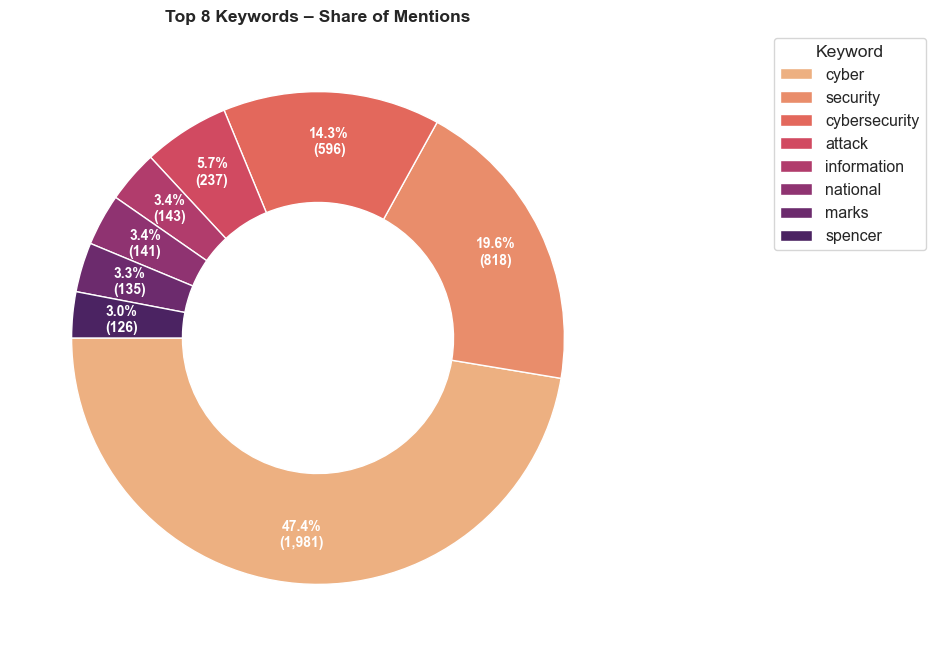

In [107]:
def plot_top_keywords_pie(df, top_n=8,#הגדרת פונקציה לציור גרף עוגה של מילות המפתח הנפוצות
                          figsize=(8, 8),# די אף מקבלת טבלה וכמה מילים להציג בחרנו 8,גודל הגאף שם פלטת הצבעים ואם יהיה לה חור באמצע עמו דונאט
                          cmap_name="flare",
                          donut=True):

    # 1) Aggregate & sort #סופר כמה פעמים הופיעה כל מילת מפתח ומסדר את העשרת המילים הכי נפוצות מהכי הרבה להכי מעט.
    top = (get_top_keywords(df, 'cleaned_keywords', top_n)#הפעלת הפונקצייה
           .sort_values('count', ascending=False)#ממין את הטבלה לפי הכי הרבה להכי מעט, המילה הפופולרית תופיע ראשונה
           .reset_index(drop=True))#מסדר את האינדקסים מאפס אותם

    #שמירת 3 רשימות
    labels = top['keyword']#שמות המילים
    sizes  = top['count']#כמות ההופעות של כל מילה
    total  = sizes.sum()#סך כל ההופעות על מנת לחשב באחוזים

    # 2) Build colour list out of the chosen colormap יוצר רשימת צבעים בשביל כל פרוסה בעוגה   
    cmap   = plt.colormaps.get_cmap(cmap_name)#לוקח את שם פלטת הצבעים שרוצי מיבא אותה  ממאטפלוטליב
    colors = cmap(np.linspace(0, 1, len(labels)))#יוצר מספרים באורך כמות המילים וממיר אותם לצבעים

    # 3) Create the figure & axes (equal aspect keeps the pie round)מייצר חלון גרף (fig) וציר גרף (ax), עם יחס שווה — כדי שהעוגה תצא עגולה ולא אליפסה.
    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(aspect="equal"))

    # 4) Draw the wedges
    wedgeprops = dict(width=0.45) if donut else None   # width<1 → donutמגדיר את הרוחב של הפרוסות בעוגה — אם donut=True אז יהיה חור באמצע (כמו דונאט),
#אחרת תהיה עוגה רגילה.

    
    wedges, texts, autotexts = ax.pie(#מצייר את גרף העוגה:
        
        sizes,
        colors=colors,
        startangle=180,              # rotate so the largest slice starts at 140°
        autopct=lambda pct:
            f"{pct:.1f}%\n({int(pct/100.*total):,})",  # show % + absolute
        pctdistance=0.8 if donut else 0.6,             # text position
        textprops=dict(color="white", weight="bold",fontsize=10),
        wedgeprops=wedgeprops
    )

    # 5) Legend on the right#שם מקרא (legend) בצד ימין — שבו רואים איזה צבע שייך לאיזו מילה.
    ax.legend(wedges, labels, title="Keyword",loc="upper right", bbox_to_anchor=(1, 0, 0.5, 1))

    # 6) Title#שם כותרת לגרף, ומחזיר את האובייקטים של הגרף (כדי שאפשר יהיה להמשיך לערוך אותם אם רוצים).
    ax.set_title(f"Top {top_n} Keywords – Share of Mentions", weight="bold")

    return fig, ax

fig, ax = plot_top_keywords_pie(posted_df, top_n=8)#מפעיל את הפונקציה על הטבלה שלך (posted_df)
plt.show()
#הפונקציה מציירת גרף עוגה צבעוני שמציג איך מתחלקות מילות המפתח הכי נפוצות בכתבות שלך, כולל אחוזים וכמות הופעות לכל מילה.



#### <div dir="rtl">חלק 4: סדרות זמן ואגרגציות (5 גרפים)</div>
<div dir="rtl">
סטטיסטיקות יומיות וברמת מדינה של פרסום וכישלון מאמרים.
</div>
<div dir="rtl">
    
- חישוב סך כל המאמרים שפורסמו בכל תאריך (`articles_per_day`) על ידי קיבוץ הנתונים בעמודת `published_date` וספירת מספר הרשומות בכל יום.
- חישוב סך כל המאמרים שנכשלו בכל תאריך (`failures_per_day`) על ידי קיבוץ הנתונים בטבלת הכישלונות בעמודת `published_date` וספירה.
- חישוב מספר המאמרים שפורסמו לפי מדינה (`posted_per_country`) ומספר המאמרים שנדחו לפי מדינה (`skipped_per_country`) באמצעות ספירת הערכים בעמודת `rss_source` בכל אחד מה-DataFrames.
- חישוב מספר הכישלונות לפי סיבה ותאריך (`failures_by_reason_date`) על ידי קיבוץ לפי עמודות `published_date` ו-`reason`, וספירה. הפלט הוא טבלה בה כל עמודה מייצגת סיבת כישלון וכל שורה מייצגת תאריך.
</div>



In [108]:
#Total articles published by dateסופר כמה כתבות פורסמו בכל תאריך:
articles_per_day = posted_df.groupby('published_date').size()
#Total failed articles by dateסופר כמה כתבות נדחו (skipped) בכל תאריך:
failures_per_day = skipped_df.groupby('published_date').size()

#Total articles published And not published by countryסופר כמה כתבות פורסמו וכמה נדחו מכל "מדינה" או מקור RSS:
posted_per_country = posted_df['rss_source'].value_counts().rename('Published')
skipped_per_country = skipped_df['rss_source'].value_counts().rename('Skipped')

#Failure reasons by dateטבלה שמציגה לכל תאריך כמה כתבות נדחו מכל סיבה:
failures_by_reason_date = skipped_df.groupby(['published_date', 'reason']).size().unstack(fill_value=0)

#### <div dir="rtl">🔸גרף 1: גרף השוואתי משולב של הצלחות מול כישלונות</div>
<div dir="rtl">
הקוד מאחד את נתוני ההצלחות והכישלונות, ובונה תרשים קווי המציג לכל יום את מספר המאמרים שפורסמו לעומת מספר המאמרים שנכשלו. הגרף ממחיש את המגמות לאורך זמן, כולל כותרות, תוויות וסימון כל תאריך בציר ה-X.
</div>



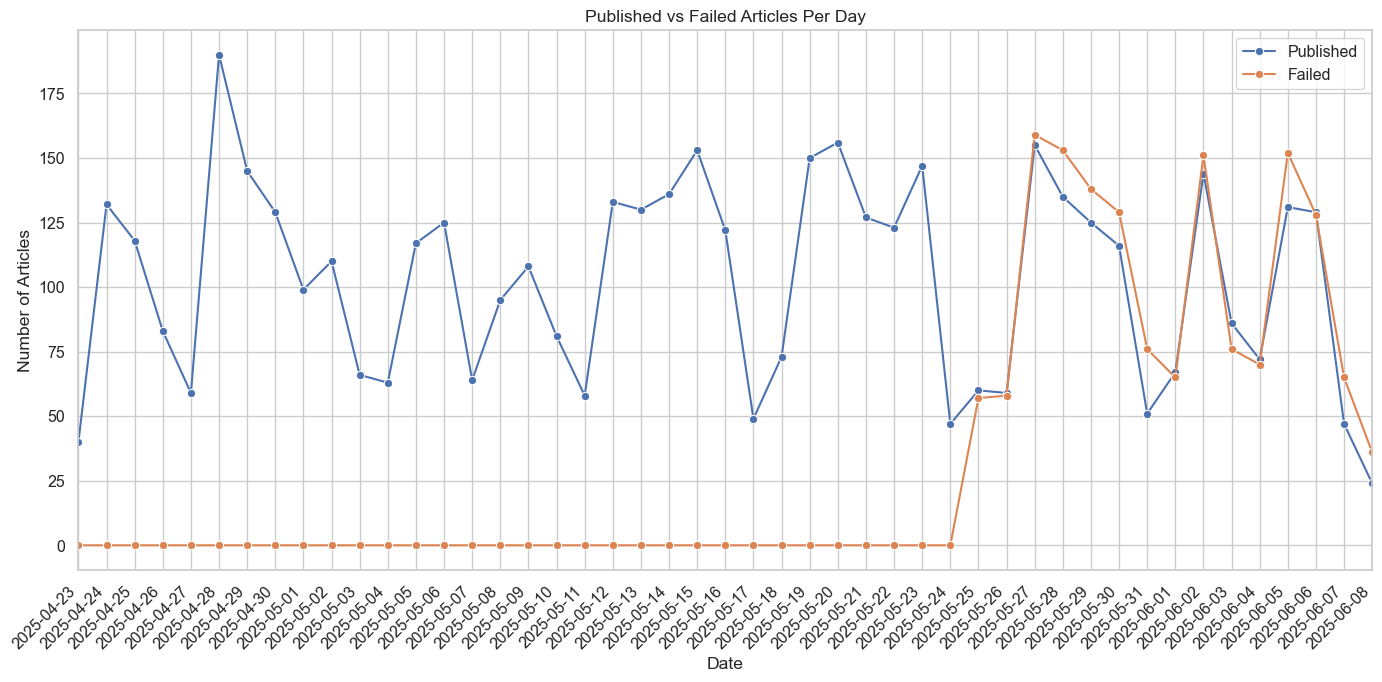

In [109]:
# Step 1: Combine published & failed counts into one DataFrame מחבר לשני עמודות — "פורסמו" ו"נכשלו" — לאותה טבלה לפי תאריך
combined_df = pd.concat([
    articles_per_day.rename('Published'),
    failures_per_day.rename('Failed')
], axis=1).fillna(0)

# Reset index to turn the dates into a column הופך את האינדקס (שהוא התאריך) לעמודה רגילה בשם 'published_date'
ts_df = combined_df.reset_index().rename(columns={'index': 'published_date'})

# Step 2: Create the line plot פותח חלון גרף בגודל 14 על 7 — להכנה לציור גרף קו (קוים) ב־matplotlib.
fig, ax = plt.subplots(figsize=(14, 7))

#מצייר שני קווי מגמה (בגרף אחד):

#הראשון מראה, לכל יום, כמה כתבות פורסמו (קו עם נקודות).

#השני מראה, לכל יום, כמה כתבות נכשלו/נדחו.

#משתמש בספריית seaborn לציור קווים יפים.

sns.lineplot(
    data=ts_df,
    x='published_date',
    y='Published',
    marker='o',
    label='Published',
    ax=ax
)
sns.lineplot(
    data=ts_df,
    x='published_date',
    y='Failed',
    marker='o',
    label='Failed',
    ax=ax
)

# Step 3: Force the x-axis to cover the entire date range (including the last date)
ax.set_xlim(#מגדיר לציר ה-X (תאריכים) שיכסה את כל טווח התאריכים מהראשון עד האחרון.
    ts_df['published_date'].min(),
    ts_df['published_date'].max()
)

# Step 4: Show every single date tick on the x-axis 
#מגדיר שהגרף יציג כל יום בציר ה-X (לא ידלג על ימים)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))   # one tick per day
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))     # format as YYYY-MM-DD
fig.autofmt_xdate(rotation=45)                              # rotate labels for readability

# Step 5: Final touches שם לגרף, שמות לצירים, רשת לרקע, מקרא (legend), עיצוב קומפקטי,
ax.set_title('Published vs Failed Articles Per Day')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Articles')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()#הצגת הגרף


#### <div dir="rtl">🔸גרף 2: שיעור הצמיחה היומי במאמרים שפורסמו</div>
<div dir="rtl">
הקוד מחשב את שיעור השינוי היומי (באחוזים) במספר המאמרים שפורסמו, יוצר ממוצע נע ל־7 ימים, ומציג גרף קווי עם שטח בצבע ירוק כאשר השינוי חיובי ואדום כאשר שלילי. בנוסף, הקוד מסמן קו אנכי עבור יום הפרסום האחרון, כולל תווית. הגרף מסייע לזהות מגמות יומיות, תנודתיות ומגמות ארוכות טווח בפרסום מאמרים.
</div>


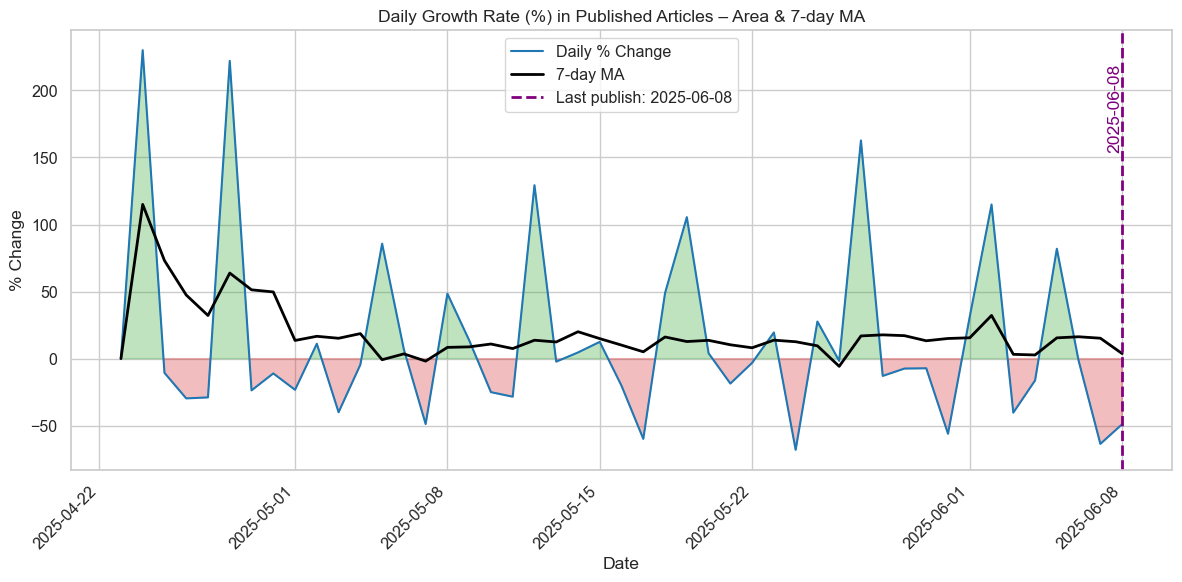

In [110]:
#מנתח את שיעור השינוי היומי במספר הכתבות שפורסמו

# Step 1: Prepare DataFrame
# — compute daily % change and reset index for plotting
growth = articles_per_day.pct_change().fillna(0) * 100#  מחשב את השינוי היחסי בין כל יום ליום הקודם וממלא 0 ליום הראשון כי אין לו יום קודם
df_growth = growth.reset_index().rename(columns={# הופך את התוצאה לטבלה חדשה עם עמודות דייט ושיעור השינוי היומי באחוזים
    'published_date': 'date',
    0: 'pct_change'
})

# Step 2: Calculate 7-day rolling average מחשב ממוצע נע של שבעה ימים
# — for each day, average that day + previous 6 days (min_periods=1 allows early days)#כל יום — לוקח את הממוצע של אותו יום + ששת הימים שלפניו 
df_growth['rolling'] = df_growth['pct_change'].rolling(window=7, min_periods=1)\# זה עוזר להחליק את הגרף ולזהות מגמות בלי קפיצות חדות
    .mean()

# Step 3: Identify the last publish date מוצא את התאריך האחרון שבו פורסמה לפחות כתבה אחת
# — pick the last index where at least one article was published
last_pub_date = articles_per_day[articles_per_day > 0].last_valid_index()

# Step 4: Create the plot פותח חלון גרף בגודל 12x6
fig, ax = plt.subplots(figsize=(12, 6))

# 4a) Plot daily % change line מצייר קו (גרף קו) של שיעור השינוי היומי (%) במספר הכתבות
sns.lineplot(data=df_growth, x='date', y='pct_change',color='tab:blue', label='Daily % Change', ax=ax
)

# 4b) Fill areas: green when positive, red when negative צובע אזורים מתחת ומעל לקו
ax.fill_between(
    df_growth['date'], df_growth['pct_change'], 0,
    where=(df_growth['pct_change'] >= 0),
    interpolate=True, color='tab:green', alpha=0.3
)

ax.fill_between(
    df_growth['date'], df_growth['pct_change'], 0,
    where=(df_growth['pct_change'] < 0),
    interpolate=True, color='tab:red', alpha=0.3
)

# 4c) Plot the 7-day moving average מצייר קו חלק שמראה את הממוצע הנע ל-7 ימים (פחות רועש, יותר יציב).

sns.lineplot(
    data=df_growth, x='date', y='rolling',
    color='black', linewidth=2, label='7-day MA', ax=ax
)

# Step 5: Mark the last publish date מסמן קו אנכי סגול (מקווקו) ביום האחרון שבו פורסמה כתבה:

# — vertical dashed line
ax.axvline(
    last_pub_date, color='purple', linestyle='--', linewidth=2,
    label=f'Last publish: {last_pub_date.strftime("%Y-%m-%d")}'
)
# — text annotation next to the line מוסיף ליד הקו תווית עם התאריך (ליד החלק העליון של הגרף).
y_max = ax.get_ylim()[1]
ax.text(
    last_pub_date, y_max * 0.9,
    last_pub_date.strftime('%Y-%m-%d'),
    rotation=90, color='purple', va='top', ha='right'
)

# Step 6: Final formatting שם לגרף, שמות לצירים, מקרא (legend), פורמט תאריכים ברור, מסובב את התאריכים ל-45 מעלות.
ax.set_title('Daily Growth Rate (%) in Published Articles – Area & 7-day MA')
ax.set_xlabel('Date')
ax.set_ylabel('% Change')
ax.legend()
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()# הצגת הגרף


#### <div dir="rtl">🔸גרף 3: התפלגות אחוזית של סיבות הכישלון</div>
<div dir="rtl">
הקוד מחשב את אחוז כל סיבת כישלון מסך כל הכישלונות, ויוצר תרשים עמודות אופקי המציג את התפלגות הסיבות. כל עמודה מראה את האחוז והכמות עבור כל סיבה.
</div>


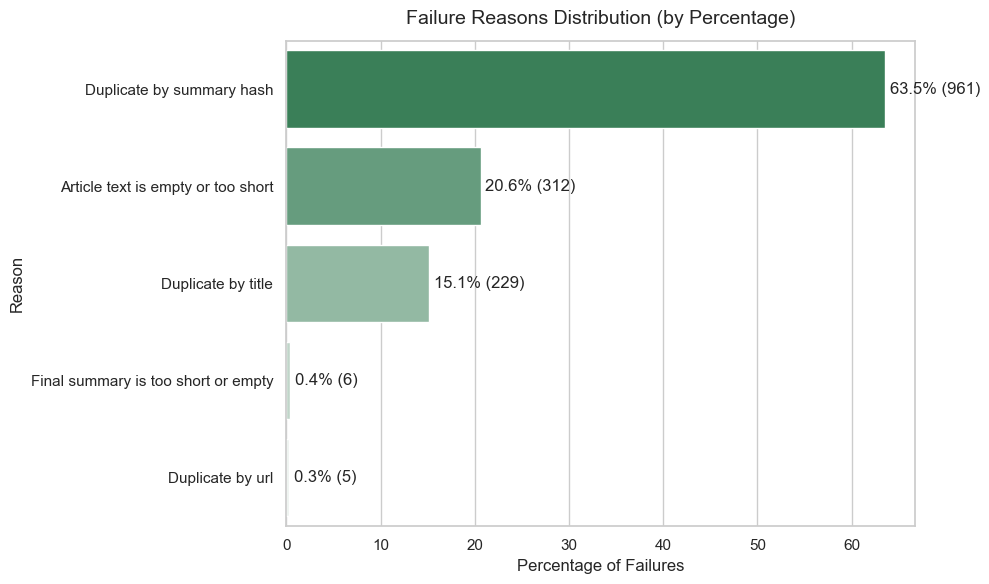

In [111]:
#בונה טבלה חדשה שמראה כמה פעמים כל סיבה לדחיית כתבה הופיעה.
reason_counts = (
    skipped_df['reason']
    .value_counts()                       # count occurrences of each reason # סופר כמה פעמים כל סיבה  מופיעה בטבלת הכישלונות
    .rename_axis('reason')                # name the index “reason”


if ax.get_legend() is not None:# מסיר את המקרא (legend) — כי הוא מיותר פה, כבר רואים את הסיבות על הציר.
    ax.get_legend().remove()

for i, row in reason_counts.iterrows():# מוסיף ליד כל בר את האחוז שלו וגם את המספר
    ax.text(
        row['pct'] + 0.5,                 # x-coordinate: slightly to the right of bar end
        i,                                 # y-coordinate: same as bar index
        f"{row['pct']:.1f}% ({row['count']})",  # text label
        va='center'                       # vertical alignment: center on the bar
    )

# Final formatting: titles and axis labels # כותרת לגרף, שמות לצירים, עיצוב סופי — ומציגים את הגרף.
ax.set_title('Failure Reasons Distribution (by Percentage)', fontsize=14, pad=12)
ax.set_xlabel('Percentage of Failures', fontsize=12)
ax.set_ylabel('Reason', fontsize=12)
plt.tight_layout()                       # adjust subplots to fit in the figure area
plt.show()                               # display the plot


#### <div dir="rtl">🔸גרף 4: מאמרים שפורסמו לעומת מאמרים שדולגו לפי מדינה</div>
<div dir="rtl">
הקוד מאחד נתונים של מאמרים שפורסמו ושנדחו לפי מדינה, ממיר את הנתונים לפורמט ארוך, ומציג גרף עמודות אופקי המשווה בין כמות המאמרים שפורסמו לכמות המאמרים שדולגו בכל מדינה. כל עמודה מייצגת מדינה, עם פירוט לפי סטטוס (פורסם/נדחה).
</div>


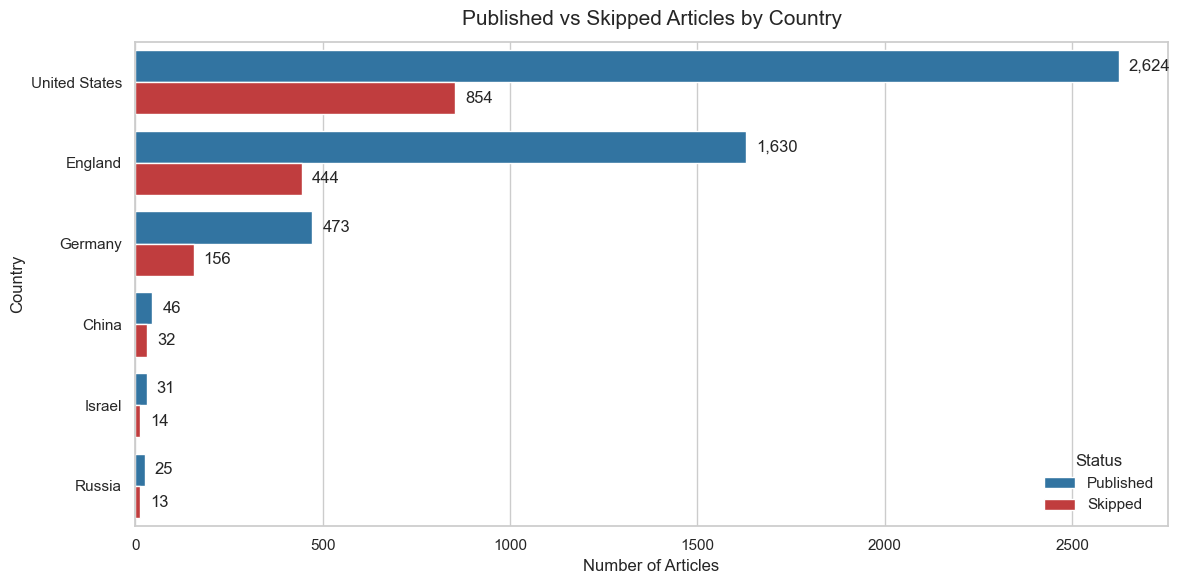

In [112]:
# Join the two series → wide table # מאחד את שתי הסדרות (פורסם, נדחה) לטבלה אחת:
country_wide = pd.concat([posted_per_country, skipped_per_country], axis=1).fillna(0).astype(int)

#משאיר בטבלה רק מדינות שיש להן לפחות כתבה אחת (פורסמה או נדחתה).
country_wide = country_wide.loc[country_wide.sum(axis=1) > 0]

# Convert to “long” format for seaborn מסדר את הטבלה כך שלכל שורה יש מדינה, סטטוס (פורסם/נדחה), וכמות.
country_long = (
    country_wide
    .sort_values('Published', ascending=False)      # order by Published
    .reset_index(names='country')                  # move index to column
    .melt(id_vars='country',                       # -> columns: country | status | count
          var_name='status',
          value_name='count')
)

# Plot grouped horizontal bars מכין גרף רקע נוח בגודל 12x6, עם רשת רקע.
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

# Custom palette: Published = blue, Skipped = red מגדיר צבע כחול ל-Published, אדום ל-Skipped.
palette = {'Published': 'tab:blue', 'Skipped': 'tab:red'}

sns.barplot( # מצייר גרף ברים אופקי שמציג, לכל מדינה, כמה כתבות פורסמו וכמה נדחו — כל סטטוס בצבע אחר ובצמוד.
    data=country_long,
    y='country', x='count',
    hue='status',            # now hue distinguishes Published vs Skipped
    palette=palette,
    dodge=True,              # side-by-side bars (horizontal grouping)
    ax=ax
)

# Annotate each bar (skip bars with width == 0) מדפיס ליד כל בר את המספר (כמות הכתבות), אבל רק אם הבר לא אפס.
for p in ax.patches:
    width = p.get_width()
    if width == 0:       # לא להדפיס טקסט על בר “ריק”
        continue
    ypos = p.get_y() + p.get_height() / 2
    ax.text(
        width + country_long['count'].max() * 0.01,
        ypos,
        f'{int(width):,}',
        va='center'
    )

ax.set_title('Published vs Skipped Articles by Country', fontsize=15, pad=12)# כותרות, עיצוב סופי, מקרא — ומציג את הגרף.
ax.set_xlabel('Number of Articles', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.legend(title='Status', frameon=False)
plt.tight_layout()
plt.show()


#### <div dir="rtl">🔸גרף 5: מפת חום – סיבת כישלון לפי תאריך</div>
<div dir="rtl">
הקוד יוצר טבלת שכיחויות של כישלונות לפי סיבה ותאריך, ומציג מפת חום (heatmap) שממחישה כמה מאמרים נכשלו בכל סיבה בכל יום. כל תא במפה מייצג את מספר הכישלונות לאותה סיבה בתאריך מסוים.
</div>


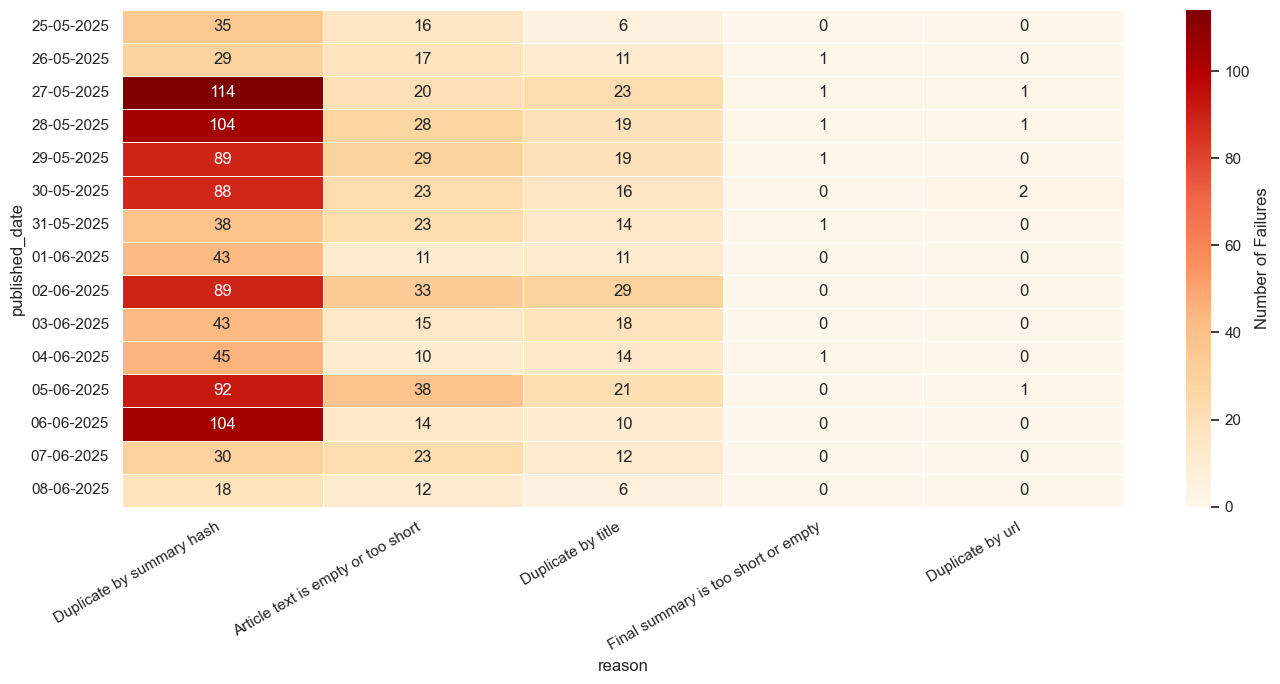

In [113]:
#סופר כמה כישלונות (נדחות) היו מכל סיבה לאורך כל התקופה, מסדר מהכי נפוצה לפחות.
order = failures_by_reason_date.sum(axis=0).sort_values(ascending=False).index 
heat_data = failures_by_reason_date[order] #מסדר את הטבלה לפי אותו סדר סיבות שנקבע למעלה.
heat_data.index = heat_data.index.strftime('%d-%m-%Y') # הופך את התאריכים שבאינדקס של השורות לפורמט תאריך ברור (יום-חודש-שנה).

fig, ax = plt.subplots(figsize=(14, 7)) #יוצר חלון גרף בגודל 14x7 אינץ'.


sns.heatmap( #מצייר את מפת החום:
    heat_data,
    cmap="OrRd",
    annot=True, fmt='d',
    linewidths=.5, linecolor='white',
    yticklabels=heat_data.index,            # index כבר מחרוזות
    cbar_kws={"label": "Number of Failures"},
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')# מסובב את שמות הסיבות בציר ה-X ב־30 מעלות שיהיה יותר קריא.
plt.tight_layout()
plt.show()#עיצוב קומפקטי והצגת הגרף.

# <div dir="rtl">🔹שלב 3: זיהוי כפילויות וזרימת פרסום לפי שעה</div>
<div dir="rtl">
בשלב זה מאתרים את המאמרים הכפולים ביותר—לפי כותרת, תקציר (hash) וכתובת URL—ולאחר מכן בונים וממחישים את זרימת הפרסומים לעומת כפילויות לפי שעות במהלך השבוע האחרון באמצעות גרף פיזור עם גודל בועות.
</div>


#### <div dir="rtl">חלק 1: זיהוי הכפילויות המובילות לפי כותרת, תקציר (Hash) ו־URL</div>
<div dir="rtl">
בקטע זה מחשבים ומציגים את המאמרים הכפולים ביותר בשלוש קטגוריות—לפי כותרת, לפי תקציר (hash), ולפי כתובת URL—כדי להבליט את מקורות הכפילות השכיחים ביותר.
</div>


In [114]:
# PARAMETERS הגדרת קבועים:
MIN_DUP   = 1 # כמה פעמים לפחות כתבה צריכה להיות משוכפלת כדי להיכנס לרשימה (ברירת מחדל 1, כלומר כל כפילות).
TOP_N     = 5 #  כמה שורות להציג בטבלה (הכי שכפולים).
# סיבות הדחייה
TITLE_REASON = 'Duplicate by title'
HASH_REASON  = 'Duplicate by summary hash'
URL_REASON  = 'Duplicate by url'

# פונקציה שמציגה את הכתבות הכי "רועשות" (כלומר הכי שכפולות) לפי סיבה מסוימת.
def show_top_dupes(df_posted: pd.DataFrame, 
                   df_skipped: pd.DataFrame,
                   reason: str,
                   count_col_out: str,
                   key_col: str,
                   min_dup: int = 2,
                   top_n: int = 10) -> pd.DataFrame:

    #סופר כמה כתבות נדחו (skipped) עבור כל ערך בשדה (למשל, כמה פעמים אותה כותרת נדחתה), עבור סיבת הדחייה הספציפית.
    # count how many skipped per key
    counts = (df_skipped[df_skipped['reason'] == reason].groupby(key_col).size())
    total_dup_in_skipped = counts.sum()

    # יוצר עמודה חדשה בפוסטד שבה לכל כתבה רשום כמה פעמים  הופיע כמשוכפלת בסקיפד
    # map counts back to posted dataframe
    df_posted[count_col_out] = (
        df_posted[key_col].map(counts).fillna(0).astype(int)
    )

    # filter only rows with at least min_dup duplicates # מסנן כתובות שעמודות הספירה שלהם שווה או מעל המינימום
    noisy = df_posted[df_posted[count_col_out] >= min_dup]

    # add percentage column שומר רק את כותרת הכתבה והעמודה של מספר הכפילויות,
    noisy = (noisy[['title', count_col_out]].assign(# מחשב מה האחוז שלה מתוך כל הכפילויות שנמצאו
            perc_of_reason=lambda x: (x[count_col_out] / total_dup_in_skipped * 100).round(1))
             
        .sort_values(count_col_out, ascending=False)# מסדר מהכי הרבה לכי מעט ושומר רק את המובילים
        .head(top_n)
    )

    
    # 5️⃣ pretty print מדפיס בצורה יפה את הטבלה — עם כותרת והנתונים עצמם.
    print(f"\n► {reason} — Top {top_n} (≥{min_dup} duplicates)")
    print(noisy.to_string(index=False))

    return noisy # מחזיר את הטבלה כדי שאפשר יהיה להמשיך לנתח/להציג/לשמור.

# RUN for title duplicates מפעיל את הפונקציה על כפילויות לפי כותרת.
top_title_dupes = show_top_dupes(
    posted_df.copy(),
    skipped_df,
    reason=TITLE_REASON,
    count_col_out='dup_titles',
    key_col='title',
    min_dup=MIN_DUP,
    top_n=TOP_N
)

# RUN for summary-hash duplicates # מפעיל את הפונקציה על כפילויות לפי סיכום/תקציר (hash).
top_hash_dupes = show_top_dupes(
    posted_df.copy(),
    skipped_df,
    reason=HASH_REASON,
    count_col_out='dup_hashes',
    key_col='text_hash',
    min_dup=MIN_DUP,
    top_n=TOP_N
)

# RUN for summary-url duplicates # בודק כפילויות לפי כתובת url.
top_hash_dupes = show_top_dupes(
    posted_df.copy(),
    skipped_df,
    reason=URL_REASON,
    count_col_out='dup_url',
    key_col='url',
    min_dup=MIN_DUP,
    top_n=TOP_N
)



► Duplicate by title — Top 5 (≥1 duplicates)
                                                                                       title  dup_titles  perc_of_reason
Chinese mainland police pursue 20 suspects involved in cyber attacks initiated by Taiwan ...           4             1.7
                                NEOM McLaren Formula E Team & Trend Micro Innovation History           3             1.3
 INE Security Alert: $16.6 Billion in Cyber Losses Underscore Critical Need for Advanced ...           3             1.3
           Texas Cyber Command will mean 'expanding' cybersecurity help, state official says           2             0.9
 'I do not have confidence' that US infrastructure is cyber-secure, former NSC official says           2             0.9

► Duplicate by summary hash — Top 5 (≥1 duplicates)
                                                                                            title  dup_hashes  perc_of_reason
A massive explosion at an Iranian port possibly l

#### <div dir="rtl">🔸גרף: זרימת פרסום וכפילויות לפי שעה</div>
<div dir="rtl">
בקטע זה בונים טבלאות שעתיות של מאמרים שפורסמו ודולגו (כפולים) במהלך השבוע האחרון, וממחישים את הזרימה שלהם באמצעות גרף פיזור עם גודל בועה.
</div>

<div dir="rtl">
הקוד בונה טבלאות שעתיות למאמרים שפורסמו ולמאמרים שזוהו ככפולים במהלך השבוע האחרון, וממחיש אותם בגרף פיזור שבו גודל הבועה מייצג את כמות המאמרים בכל שעה וסיבה. הצבעים מייצגים את סטטוס הפרסום (פורסם או סוג כפילות), והגרף מסייע לנתח דפוסי פרסום וכפילויות לאורך שעות היממה.
</div>


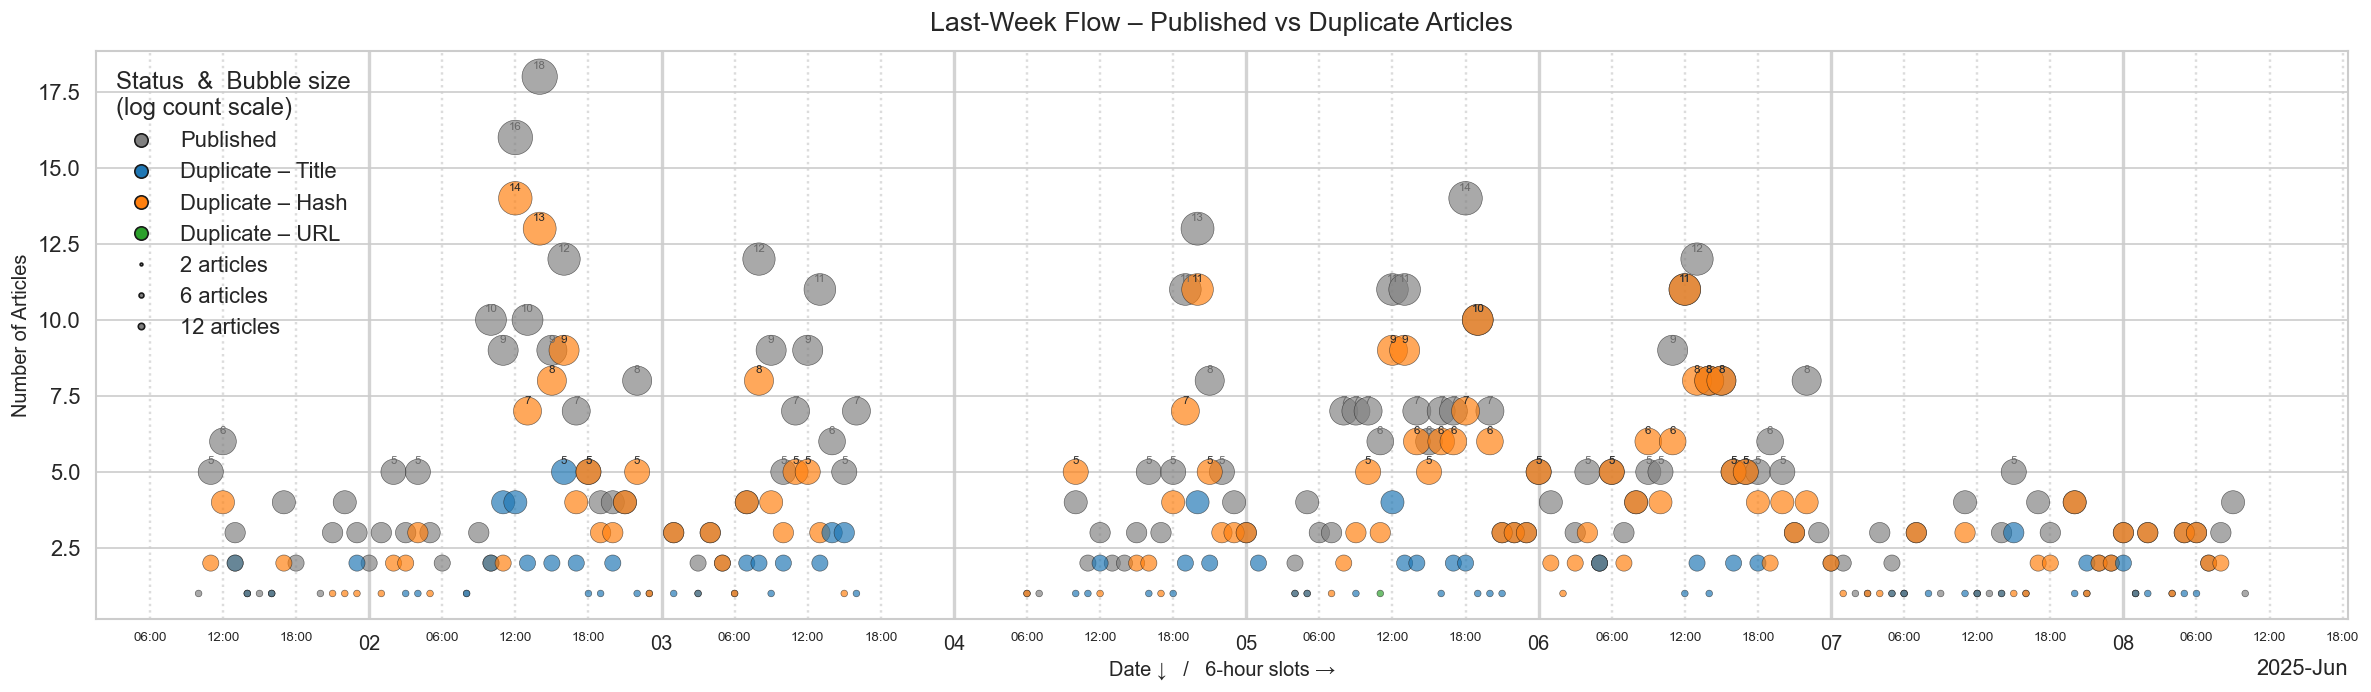

In [115]:
warnings.filterwarnings('ignore', category=FutureWarning, module='pandas')

#פונקציה שיוצרת טבלאות לפי שעות, לשבוע האחרון, להשוואה בין כתבות שפורסמו לכפילויות שנדחו.
def build_hourly_tables(
        posted_df : pd.DataFrame,
        skipped_df: pd.DataFrame,
        window_days : int = 7,
        scale       : int = 6
    ) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    # מחברת בין תאריך לשעה לכל כתבה, ממירה לאובייקט תאריך-שעה, ומורידה לדקה הקרובה (שעת עגולה).
    for df in (posted_df, skipped_df):
        df['pub_hour'] = ( pd.to_datetime(
                df['published_date'].astype(str) + ' ' +df['published_time'].astype(str),errors='coerce').dt.floor('h'))

    end = max(posted_df['pub_hour'].max(), skipped_df['pub_hour'].max())# מגדיר טווח זמן: מתי היה הפרסום/דחיה האחרון — ומה-7 ימים אחורה.
    start = end - pd.Timedelta(days=7)

    #שומר ב-pw רק את הכתבות שפורסמו בשבוע האחרון.
    pw = posted_df.loc[(posted_df['pub_hour'] >= start) & (posted_df['pub_hour'] <= end)].copy()

    duplicate_reasons = [# בוחר רק כפילויות מסוימות מה-skipped
        'Duplicate by title',
        'Duplicate by summary hash',
        'Duplicate by url']

    # # סינון הכתבות שנדחו בשבוע האחרון, רק אלה שנפסלו בגלל כפילויות (ולא סיבות אחרות).
    sw = (skipped_df.loc[(skipped_df['pub_hour'] >= start) & (skipped_df['pub_hour'] <= end)]
        .loc[skipped_df['reason'].isin(duplicate_reasons)].copy())

    # מייצר טבלה עם כמות הכתבות שפורסמו כל שעה (published),
    posted_hourly = (pw.groupby('pub_hour').size().reset_index(name='count').assign(reason='Published'))

    # וטבלה נוספת עם כמות הכפילויות שנדחו, מחולקות לפי שעה ולפי סוג כפילות.
    skipped_hourly = (sw.groupby(['pub_hour', 'reason']).size().reset_index(name='count'))

    # מחשב את גודל הבועה שתשמש לגרף — לוקח לוגריתם של הספירה כדי "להרגיע" הבדלים קיצוניים.
    for gdf in (posted_hourly, skipped_hourly):
        gdf['bubble_size'] = np.log1p(gdf['count']) * scale

    # מחבר הכל לטבלה אחת — שעה, כמות, סיבה, וגודל בועה.
    plot_df = pd.concat([posted_hourly, skipped_hourly], ignore_index=True) \
               [['pub_hour', 'count', 'reason', 'bubble_size']]

    # מחזיר שלוש טבלאות: לכל הגרף, לפורסמו, ולכפילויות שנדחו
    return plot_df, posted_hourly, skipped_hourly

# מצייר גרף שמראה, לכל שעה, כמה כתבות פורסמו וכמה נדחו מכל סיבה, עם בועות בגודל משתנה (Bubble Chart).
def plot_hourly_flow(
        plot_df       : pd.DataFrame,
        posted_hourly : pd.DataFrame,
        skipped_hourly: pd.DataFrame) -> None:

    # הגדרות עיצוב — צירים, צבעים, פורמטים
    class DateFmt(mdates.ConciseDateFormatter):
        def format_tick(self, x, _):
            return mdates.num2date(x).strftime('%d.%m') 
            
    class HourFmt(mdates.ConciseDateFormatter):
        def format_tick(self, x, _):
            return mdates.num2date(x).strftime('%H:%M') 

    major = mdates.DayLocator()
    minor = mdates.HourLocator(byhour=[0, 6, 12, 18]) 

    palette = {
        'Published'                 : 'grey',
        'Duplicate by title'        : 'tab:blue',
        'Duplicate by summary hash' : 'tab:orange',
        'Duplicate by url'          : 'tab:green'}

    sns.set_theme(style="whitegrid", font_scale=1.2) 
    fig, ax = plt.subplots(figsize=(20, 6), dpi=120) 

    
    sns.scatterplot( # מצייר כל שעה כנקודה (בועה):
        data=plot_df,
        x='pub_hour', y='count', # גובה = כמות כתבות
        hue='reason', size='bubble_size', # צבע = סיבה (פורסם/כפילות)
        palette=palette, sizes=(16, 450), # גודל בועה = כמות כתבות (בסולם לוגריתמי)
        edgecolor='k', linewidth=.35, alpha=.68, ax=ax)

    # רושם מעל כל בועה שיש בה לפחות 5 כתבות את המספר.
    for _, r in posted_hourly[posted_hourly['count'] >= 5].iterrows():
        ax.text(r['pub_hour'], 
                r['count'] + .25, 
                r['count'],ha='center',
                fontsize=7, color='dimgray') 
        
    for _, r in skipped_hourly[skipped_hourly['count'] >= 5].iterrows(): 
        ax.text(r['pub_hour'], r['count'] + .25, r['count'],ha='center', fontsize=7)

    # עיצוב סופי — קווי רשת, פורמט תאריכים, מקרא, כותרות
    ax.xaxis.set_major_locator(major)
    ax.xaxis.set_minor_locator(minor)
    ax.xaxis.set_major_formatter(DateFmt(major)) 
    ax.xaxis.set_minor_formatter(HourFmt(minor)) 

    ax.grid(which='major', axis='x', linestyle='-', linewidth=2, color='lightgrey') 
    ax.grid(which='minor', axis='x', linestyle=':', linewidth=1.45, color='gainsboro')

    ax.tick_params(axis='x', which='major', labelsize=12) 
    ax.tick_params(axis='x', which='minor', labelsize=8)
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center') 

    sample_n = [2, 6, 12]
    size_handles = [
        Line2D([0], [0], marker='o', linestyle='', 
               markersize=np.log1p(n) * 1.5,
               markerfacecolor='grey', markeredgecolor='k',
               label=f'{n} articles') for n in sample_n]

    status_handles = [ Line2D([0], [0], marker='o', markersize=8, linestyle='', markerfacecolor=palette[key], markeredgecolor='k', label=label)
        for key, label in [
            ('Published',                 'Published'),
            ('Duplicate by title',        'Duplicate – Title'),
            ('Duplicate by summary hash', 'Duplicate – Hash'),
            ('Duplicate by url',          'Duplicate – URL')] ]

    ax.legend(handles=status_handles + size_handles,
              title='Status  &  Bubble size\n(log count scale)',
              frameon=False, 
              loc='upper left')

    ax.set_title('Last-Week Flow – Published vs Duplicate Articles', fontsize=16, pad=12)
    ax.set_xlabel('Date ↓   /   6-hour slots →', fontsize=12)
    ax.set_ylabel('Number of Articles', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_df, posted_hourly, skipped_hourly = build_hourly_tables(posted_df, skipped_df) # קריאה לפונקציות
plot_hourly_flow(plot_df, posted_hourly, skipped_hourly)


# <div dir="rtl">🔹שלב 4: אשכול נושאים וניתוח מגמות</div>
<div dir="rtl">
בשלב זה ממירים את המאמרים לוקטורים, מאשכלים אותם לפי דמיון סמנטי, מחשבים סיכומים ודוגמאות לכל אשכול, מציגים את מגמות הפרסום של כל נושא, ומנתחים את הפיצול בין מאמרים ייחודיים לכפולים.
</div>


#### <div dir="rtl">חלק 1: שילוב כותרת ותקציר, טעינת מודל שפה והמרה לווקטורים</div>
<div dir="rtl">
בקטע זה משלבים את הכותרת והתקציר של כל מאמר לשדה טקסט אחד (`super_text`), טוענים את מודל השפה paraphrase-MiniLM-L6-v2, וממירים את כל שורות הטקסט לוקטורים מספריים (embedding) עבור אשכול נושאים בהמשך.
</div>


In [116]:
from sklearn.cluster import DBSCAN # אלגוריתם לקיבוץ לפי וקטורים

# יוצר עמודה חדשה בשם סופר טקסט מחבר כל כותרת וכל סיכום כתבה לשדה טקסט ארוך אחד
posted_df['super_text'] = posted_df['title'].astype(str) + " " + posted_df['summary'].astype(str)
# ספרייה שממירה טקסטים לוקטורים
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Convert each article into a numerical embedding vector representing its content
# ניתן לראות שהכל הומר לפי הבר
embeddings = model.encode(posted_df['super_text'].tolist(), show_progress_bar=True)


Batches:   0%|          | 0/151 [00:00<?, ?it/s]

#### <div dir="rtl">חלק 2: אשכול באמצעות DBSCAN וספירת נושאים וכפילויות</div>
<div dir="rtl">בקטע זה מתבצע אשכול (Clustering) של מאמרים לפי דמיון סמנטי באמצעות האלגוריתם DBSCAN. האלגוריתם פועל על הווקטורים המייצגים את תוכן המאמרים (embeddings) ומסווג כל מאמר לקבוצת נושא (cluster), או משייך אותו לרעש (noise) אם אינו דומה מספיק לשום קבוצה.
    
 ##### <div dir="rtl">הפרמטרים המשמשים לאשכול:</div>
- <b>eps=0.19</b>: רדיוס החיפוש – כמה דומים צריכים להיות שני מאמרים כדי להיחשב כשכנים (ככל שהערך קטן יותר, האשכולות יהיו "צפופים" יותר).
- <b>min_samples=2</b>: מינימום שכנים ליצירת אשכול – נדרש לפחות שני מאמרים דומים כדי להיחשב כקבוצה.
- <b>metric='cosine'</b>: מדד דמיון קוסינוס – משמש למדידת מרחק בין וקטורי embedding (רלוונטי ל-NLP).
 <div dir="rtl">
כל מאמר מקבל מזהה נושא (`topic_id`) לפי האשכול שבו שובץ, או ‎–1 אם הוא סווג כרעש (מאמר ייחודי שלא דומה לאחרים).
לבסוף, הקוד סופר את מספר האשכולות (נושאים) האמיתיים, את מספר המאמרים שסווגו כרעש, ומציג סיכום של התוצאות.
תהליך זה מסייע לאתר קבוצות של מאמרים דומים מבחינה סמנטית, וגם לזהות מאמרים חריגים שאין להם דומים.
</div>



In [117]:
# 2. Apply DBSCAN on the embeddings
# eps: radius around each point – how close points need to be to be considered neighbors
# min_samples=2: minimum number of neighbors required to form a cluster
# metric='cosine': measure distance between embeddings using cosine distance
db = DBSCAN(eps=0.19, min_samples=2, metric='cosine')
labels = db.fit_predict(embeddings)  # labels – each article’s cluster ID (integer), or -1 if it’s noise
posted_df['topic_id'] = labels       # add a new column to the DataFrame with cluster IDs (or -1 for noise)

# 3. Count clusters and noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # compute the number of real clusters (exclude -1 for noise)
n_noise = (labels == -1).sum()                             # count how many articles weren’t assigned to any cluster
print(f"\nDBSCAN: Found {n_clusters} topics (clusters) and {n_noise} noise articles (not assigned to any topic).\n")  # summary printout



DBSCAN: Found 310 topics (clusters) and 3793 noise articles (not assigned to any topic).



#### <div dir="rtl">חלק 3: חישוב גודל נושא וסינון אשכולות מובילים</div>
<div dir="rtl">
בקטע זה לכל מאמר מחושב כמה מאמרים נוספים משתייכים לאותו נושא (topic_id), למעט מאמרים שמסווגים כרעש (noise). לאחר מכן, מסננים החוצה את המאמרים שלא שובצו לשום נושא, ובוחרים את חמשת האשכולות הגדולים ביותר – כלומר, נושאים שבהם יש לפחות חמישה מאמרים בכל אשכול.
    
<div dir="rtl"> הסבר על התהליך:
    
- עבור כל מאמר שמסווג לאשכול, הקוד מחשב כמה "עמיתים" (peers) יש לו – כלומר, כמה מאמרים נוספים חולקים את אותו topic_id.
- מאמרים שמסומנים כרעש (topic_id == -1) מקבלים ערך 0.
- יוצרים DataFrame חדש שכולל רק את המאמרים ששויכו לאשכול (ומסננים החוצה את כל ה-noise).
- מחשבים את גודל כל אשכול (כלומר, כמה מאמרים בכל נושא).
- בוחרים את חמשת האשכולות הגדולים ביותר מתוך אלה שבהם יש לפחות חמישה מאמרים.
תהליך זה עוזר למקד את הניתוח בנושאים הבולטים והמשמעותיים, תוך התעלמות ממאמרים בודדים או נושאים קטנים.
</div>


In [118]:
# Compute similar_articles and similar_count based on topic_id
def get_similar_articles(idx, topic_id, labels):
    if topic_id == -1:
        return []
    # Find all articles with the same topic_id (excluding itself)
    indices = np.where(labels == topic_id)[0]  # Find all indices of articles in the same cluster
    # Return the indices of similar articles (excluding itself)
    return [int(i) for i in indices if i != idx]

posted_df['similar_count'] = (
    posted_df.groupby('topic_id')['topic_id']        # For each topic, get the series of topic IDs
             .transform('size')                      # Repeat cluster size for each row
             .sub(1)                                 # Exclude the article itself
             .where(posted_df['topic_id'] != -1, 0)  # Assign 0 for noise articles
)

# Create DataFrame of only significant topics (e.g., with 5 or more articles)
topic_df = posted_df[posted_df['topic_id'] != -1].copy()  # Filter to include only clustered articles (exclude noise)
topic_df['topic_id'] = topic_df['topic_id'].astype(int)   # Convert cluster IDs to integers
topic_sizes = topic_df['topic_id'].value_counts()        # Count how many articles are in each cluster
# Select the top 5 largest clusters (at least 5 articles each)
large_topics = topic_sizes[topic_sizes >= 5].index.tolist()
print(f"Selected the top 5 strongest topics (out of {sum(topic_sizes >= 5)} topics with at least 5 articles)")


Selected the top 5 strongest topics (out of 43 topics with at least 5 articles)


#### <div dir="rtl">חלק 4: איגוד ותצוגת סיכום עבור נושאים חזקים</div>
<div dir="rtl">
בקטע זה מאגדים את חמשת האשכולות הגדולים ביותר כדי לחשב עבור כל נושא סטטיסטיקות מרכזיות: מספר מאמרים, תאריך פרסום ראשון ואחרון, המדינה/מקור העיקרי, ורשימת מזהי המאמרים. לאחר מכן מציגים דוגמאות של מאמרים מתוך כל נושא – כולל תאריך, מקור, וחלק מכותרת המאמר.
<div dir="rtl"> הסבר התהליך:
    
- בוחרים את כל המאמרים ששויכו לאחד מחמשת הנושאים הגדולים.
- מבצעים קיבוץ לפי מזהה נושא (topic_id) ומחשבים לכל נושא: גודל, טווח תאריכים, מקור עיקרי ורשימת מזהי מאמרים.
- בונים טבלת סיכום של כל הנושאים החזקים.
- מדפיסים לכל נושא דוגמאות של מאמרים עם תאריך, מקור וחלק מהכותרת.
השלב הזה עוזר לזהות במהירות נושאים דומיננטיים, להבין את הפיזור שלהם ולסקור מאמרים מייצגים לכל נושא.
</div>


In [119]:
# --- Build an aggregated summary for the “strong” topics only ----------------
agg_df = (
    # Keep rows whose topic_id is in the list large_topics
    topic_df.loc[topic_df['topic_id'].isin(large_topics)]
            # Group by topic_id – everything that follows runs per-topic
            .groupby('topic_id')
            # Aggregate several statistics for each topic
            .agg(
                num_articles=('topic_id', 'size'),                 # how many articles in the topic
                first_date   =('published_date', 'min'),          # earliest publication date
                last_date    =('published_date', 'max'),          # latest  publication date
                main_country =('rss_source',
                               lambda x: x.mode()[0]),            # most frequent country (rss_source)
                article_ids  =('topic_id',
                               lambda x: x.index.tolist())         # list of article indices belonging to the topic
            )
            # Put topic_id back as a normal column instead of an index
            .reset_index()
)

# --- Final summary table: keep only the rows whose topic_id appears in large_topics
#     (strictly redundant here because agg_df already contains only those IDs,
#      but it is a safe guard if large_topics is modified later).
topic_summary = agg_df.loc[agg_df['topic_id'].isin(large_topics)]


In [120]:
print("\n=== Examples of topics with at least 5 articles ===")
for topic in large_topics: 
    subset = topic_df[topic_df['topic_id'] == topic].sort_values('published_date')
    print(f"\n Topic ID: {topic} - {len(subset)} articles")
    for _, row in subset.iterrows():
        print(f"  - {row['published_date'].date()} | {row['rss_source']} | {row['title'][:95]}.")


=== Examples of topics with at least 5 articles ===

 Topic ID: 7 - 87 articles
  - 2025-04-24 | United States | M&S takes systems offline as 'cyber incident' lingers - The Register.
  - 2025-04-24 | United States | M&S struggles to get on top of 'cyber incident' - The Irish Times.
  - 2025-04-24 | United States | M&S systems remain offline days after cyber incident - Computer Weekly.
  - 2025-04-25 | United States | M&S cyberattack: online orders suspended after week of disruption - The Times.
  - 2025-04-25 | England | M&S suspends online orders after cyber incident - Sharecast.com.
  - 2025-04-25 | England | M&S halts all online orders amid ongoing disruption caused by cyber attack - ITVX.
  - 2025-04-25 | United States | M&S halts online orders as 'cyber incident' gets worse - The Register.
  - 2025-04-25 | England | M&S pauses online and app orders following cyber attack - The Herald.
  - 2025-04-25 | England | Marks and Spencer pauses online orders after reported hacking inciden

#### <div dir="rtl">חלק 5: מגמות פרסום לנושאים מובילים – גרף יומי וממוצע נע</div>
<div dir="rtl">
בקטע זה, עבור כל אחד מחמשת הנושאים המרכזיים, סופרים את מספר המאמרים שפורסמו בכל יום, מחשבים ממוצע נע בן יומיים, ומשרטטים גרף המציג גם את המספרים האמיתיים בכל יום וגם את המגמה (moving average).  
כך ניתן לראות בצורה ויזואלית איך פורסמו מאמרים בכל נושא לאורך זמן ולאתר מגמות או שיאים בולטים.
</div>


Plotting trends for these 5 topics: [7, 82, 251, 75, 73]


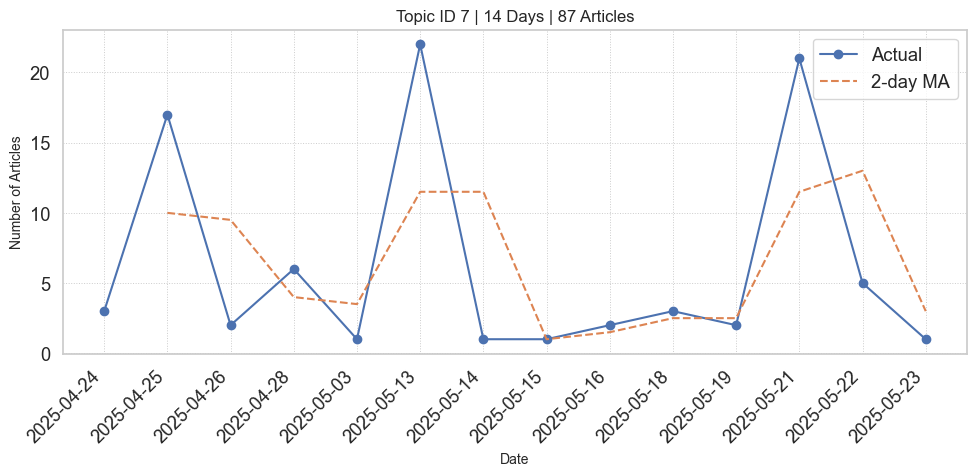

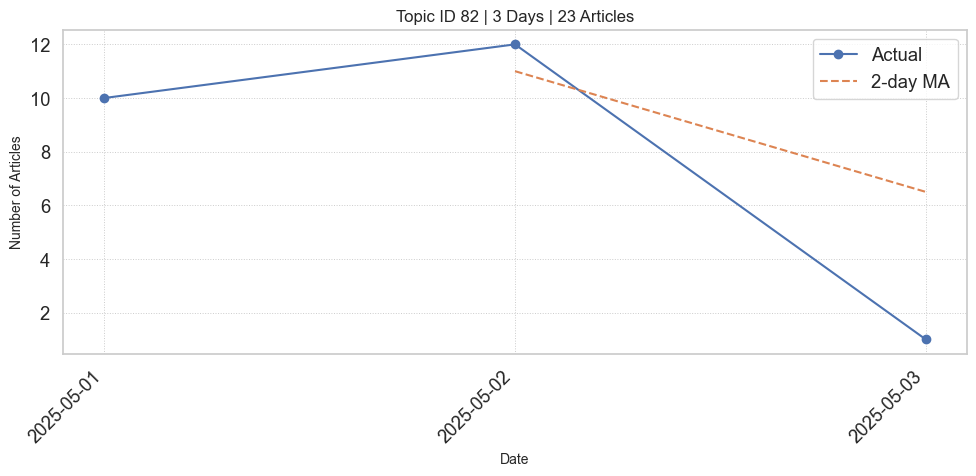

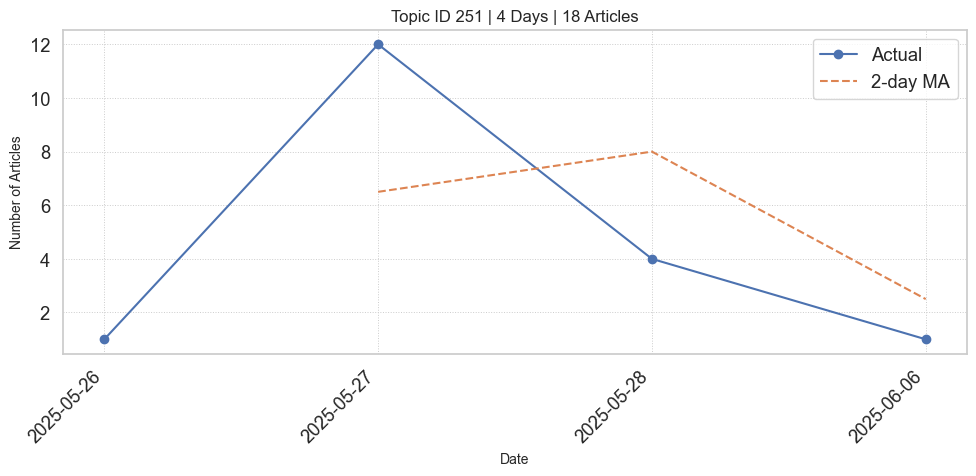

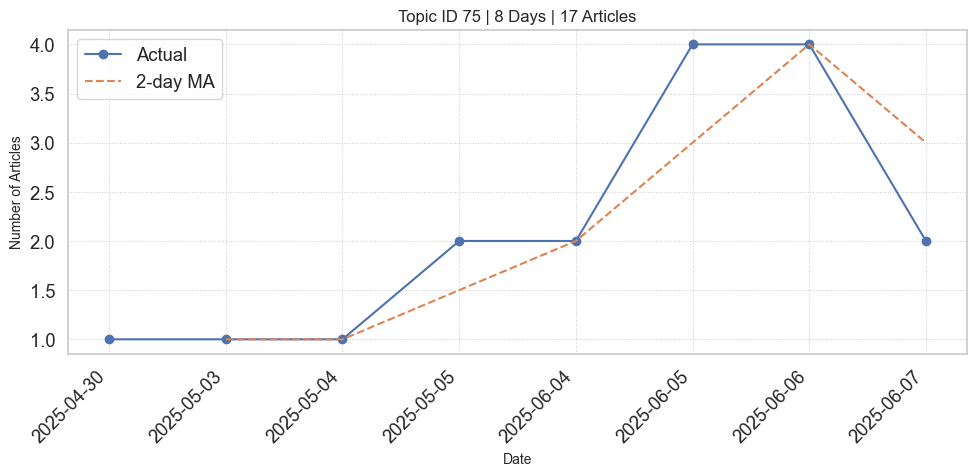

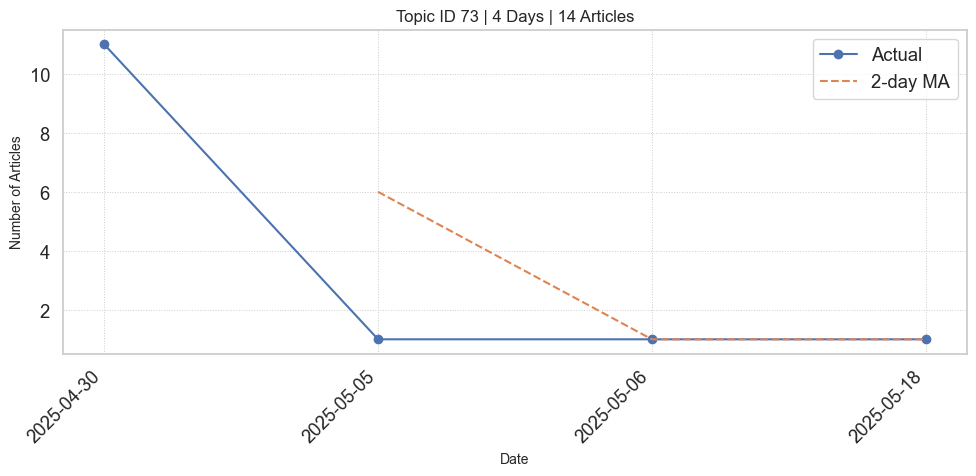

In [121]:
topic_sizes  = topic_df['topic_id'].value_counts()
large_topics = [t for t, sz in topic_sizes.items() if sz >= 5]

# 2️⃣ מתוך אלה – השאר רק מי שמתפרס על לפחות 3 ימים שונים
eligible = [
    t for t in large_topics
    if topic_df.loc[topic_df['topic_id']==t, 'published_date'].nunique() >= 3
]

# 3️⃣ מיין את ה־eligible לפי גודל אשכול (יורד) ובחר 5 ראשונים
eligible.sort(key=lambda t: topic_sizes[t], reverse=True)
top5_topics = eligible[:5]
print("Plotting trends for these 5 topics:", top5_topics)

# 4️⃣ לולאת השרטוט – עבור כל אחד מה־top5
for topic in top5_topics:
    subset      = topic_df[topic_df['topic_id'] == topic]
    # 4.1 ספירת כתבות לפי יום, ממוינת כרונולוגית
    topic_dates = subset['published_date'].value_counts().sort_index()
    # 4.2 ממוצע נע בן יומיים
    ma          = topic_dates.rolling(window=2).mean()

    # הפיכת אינדקסי התאריכים למחרוזות 'YYYY-MM-DD' להצגה על הציר
    dates      = topic_dates.index.strftime('%Y-%m-%d')
    ma_dates   = ma.index.strftime('%Y-%m-%d')

    # 4.3 יצירת הגרף
    plt.figure(figsize=(10, 5))
    plt.plot(  dates,      topic_dates.values, marker='o', label='Actual')
    plt.plot( ma_dates,    ma.values,          linestyle='--', label='2-day MA')
    plt.title(f"Topic ID {topic} | {len(topic_dates)} Days | {len(subset)} Articles", fontsize=12)
    plt.xlabel("Date", fontsize=10)
    plt.ylabel("Number of Articles", fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(True, linestyle=':', linewidth=0.7)
    plt.tight_layout()
    plt.show()

#### <div dir="rtl">חלק 6: השוואה בין מאמרים ייחודיים למאמרים עם כפילויות</div>
<div dir="rtl">
בקטע זה מחשבים כמה מאמרים אין להם אף מאמר דומה ("ייחודיים") וכמה יש להם כפילויות (כלומר, דומים לאחרים), ומציגים גרף עמודות המשווה בין שתי הקבוצות – כולל אחוזים ומספרים מוחלטים לכל קטגוריה.
</div>


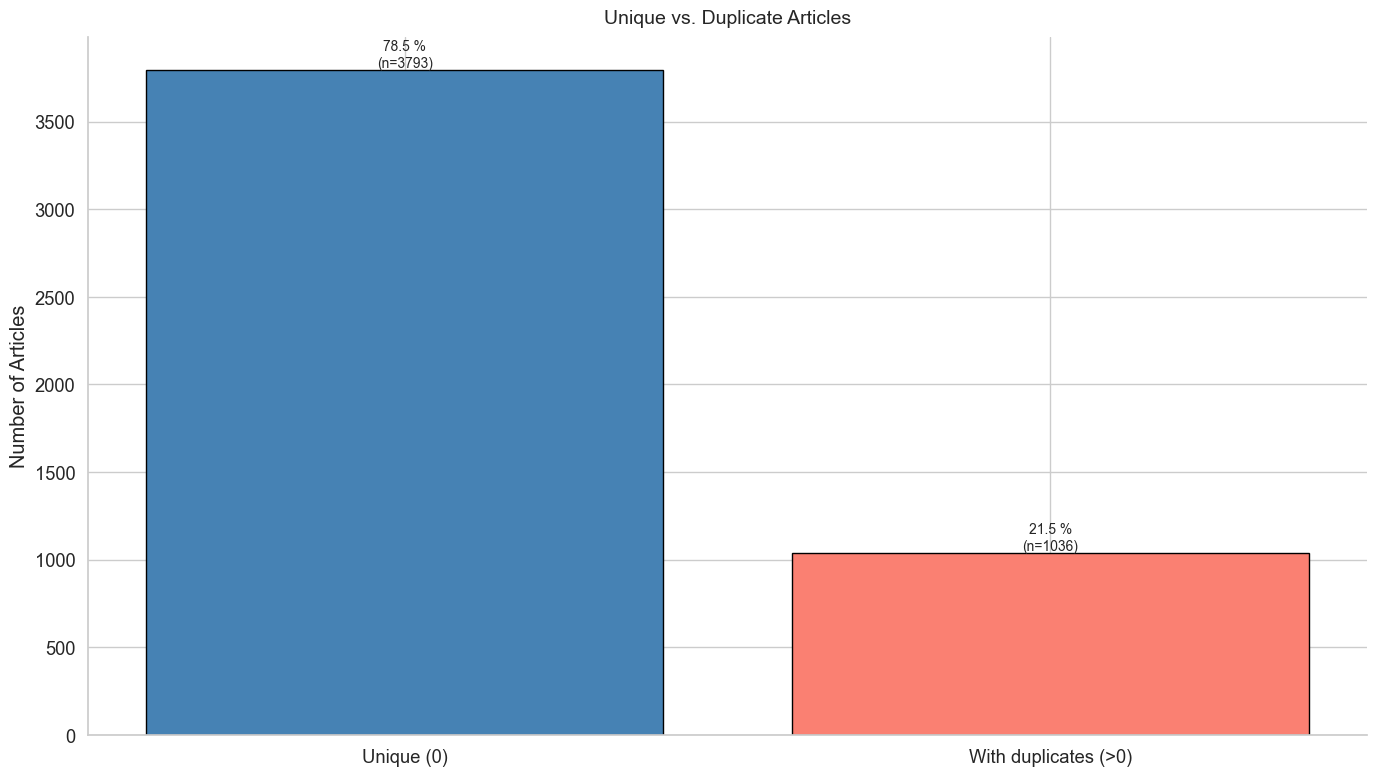

In [122]:
counts = posted_df['similar_count'].eq(0).value_counts().rename(index={True: 'Unique (0)', False: 'With duplicates (>0)'})
percent = (counts / counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.bar(counts.index, counts.values, color=['steelblue', 'salmon'], edgecolor='black')

for bar, pct, n in zip(bars, percent, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{pct} %\n(n={n})', ha='center', va='bottom', fontsize=10)

ax.set_title('Unique vs. Duplicate Articles', fontsize=14, pad=10)
ax.set_ylabel('Number of Articles')
sns.despine(); plt.tight_layout(); plt.show()


# <div dir="rtl">🔹שלב 5: איגוד תקצירי נושאים והנדסת מאפייני מגמה</div>
<div dir="rtl">
בשלב זה מאחדים את כל האשכולות ל־topics_df המרכזי, מחשבים וממפים מדדי מגמה עיקריים (מספר ימי פעילות, מקסימום מאמרים ביום, זיהוי "ספייק" או צמיחה), מסווגים את סוג המגמה של כל נושא (Spike/Growth/Both/None), ומאתרים את יום הפרסום הדומיננטי עבור כל נושא.
</div>


#### <div dir="rtl">חלק 1: בניית DataFrame מרכזי של נושאים (topics_df) על סמך איגוד מאפיינים עיקריים</div>
<div dir="rtl">
בקטע זה מאגדים לכל אשכול (נושא) את המטא-דאטה המרכזית: מספר המאמרים באשכול, תאריכי הפרסום הראשון והאחרון, המדינה/מקור העיקרי, חמש מילות המפתח הבולטות, וכותרת מייצגת קצרה.
</div>


In [123]:
topics_df = (
    topic_df.sort_values('published_date').groupby('topic_id').agg(
    num_articles=('ID', 'count'),  
    first_date=('published_date', 'min'), 
    last_date=('published_date', 'max'),  
    main_country=('rss_source', lambda x: x.mode()[0] if not x.mode().empty else None), 
    top_keywords=('cleaned_keywords', lambda x: ', '.join(pd.Series([kw for kws in x for kw in kws]).value_counts().head(5).index)),
    short_title=('title', 'first')
).reset_index())

#### <div dir="rtl">חלק 2: חישוב מדדי מגמה עבור כל נושא</div>
<div dir="rtl">
בקטע זה מחשבים לכל נושא (אשכול) את מספר ימי הפרסום השונים (`topic_day_counts`), את המספר המקסימלי של מאמרים שפורסמו ביום אחד (`max_articles_per_day`), ומגדירים דגלים בוליאניים (True/False) לזיהוי אירועי "ספייק" (לפחות 4 מאמרים ביום) ושלבי צמיחה (נוכחות בלפחות 3 ימים שונים).
</div>


In [124]:
topic_day_counts = topic_df.groupby('topic_id')['published_date'].nunique() 

max_articles_per_day = (topic_df.groupby(['topic_id', 'published_date']).size().groupby('topic_id').max()) 

spike_condition = max_articles_per_day >= 4     
growth_condition = topic_day_counts >= 3        

#### <div dir="rtl">חלק 3: מיפוי מדדי מגמה לכל נושא ב־topics_df</div>
<div dir="rtl">
בקטע זה ממפים את מדדי המגמה שחושבו לכל נושא אל טבלת הנושאים הראשית (`topics_df`), ומוסיפים עמודות חדשות: מספר ימי פעילות, מקסימום מאמרים ביום, ודגלים לזיהוי "ספייק" ולשלב צמיחה, לפי מזהה הנושא (topic_id).
</div>


In [125]:
topics_df['num_days'] = topics_df['topic_id'].map(topic_day_counts)
topics_df['max_articles_per_day'] = topics_df['topic_id'].map(max_articles_per_day)
topics_df['spike_detected'] = topics_df['topic_id'].map(spike_condition) 
topics_df['growth_detected'] = topics_df['topic_id'].map(growth_condition) 

#### <div dir="rtl">חלק 4: הנדסת מאפייני מגמה וסיכום נושא</div>
<div dir="rtl">
בקטע זה מאגדים את כל האשכולות אל תוך topics_df, ממפים את מדדי המגמה שחושבו (מספר ימי פעילות, מקסימום מאמרים ביום, דגלי Spike ו־Growth), מסווגים את סוג המגמה לכל נושא (Spike / Growth / Both / None) לפי השילוב בין הדגלים, ומאתרים עבור כל נושא את יום הפרסום הדומיננטי ביותר.
</div>


In [126]:
def classify_trend(spike, growth):
    if spike and growth:
        return 'Both'
    elif spike:
        return 'Spike'
    elif growth:
        return 'Growth'
    else:
        return 'None'

topics_df['trend_type'] = topics_df.apply(
    lambda row: classify_trend(row['spike_detected'], row['growth_detected']),
    axis=1
)

dominant_day = (topic_df.groupby(['topic_id', 'published_date']).size()
                        .groupby('topic_id').idxmax()  
                        .apply(lambda x: x[1])) 

topics_df['dominant_day'] = topics_df['topic_id'].map(dominant_day) 


# <div dir="rtl">🔹שלב 6: סיום סיכומים והכנסה למסד הנתונים</div>
<div dir="rtl">
בשלב זה מאחדים את טבלת סיכום הנושאים הסופית ומכניסים כל נושא, מאמר ומגמת טרנד חדשים אל הטבלאות המתאימות במסד הנתונים.
</div>

#### <div dir="rtl">חלק 1: בחירה וסידור סופי של עמודות בתמצית הנושאים</div>
<div dir="rtl">
בקטע זה בוחרים ומסדרים מחדש את העמודות המרכזיות ב־ topics_df, מתמקדים בשדות סיכום ומגמה עיקריים, ומציגים את השורות הראשונות כדי לוודא את מבנה הטבלה.
</div>


In [127]:
topics_df = topics_df[[
    'topic_id', 'short_title', 'trend_type',
    'num_articles', 'num_days', 'max_articles_per_day',
    'first_date', 'dominant_day', 'last_date', 'main_country',
    'top_keywords', 'spike_detected', 'growth_detected']]

print(topics_df.head())

   topic_id                                        short_title trend_type  \
0         0  FBI: Cybercrime cost victims 'staggering' $16....       None   
1         1  Thales and Deloitte align to offer advanced cy...       None   
2         2  TOKYO, Apr 24, 2025 - NEC Corporation (NEC; TS...       None   
3         3  Not just any cyber incident...but an M&S cyber...     Growth   
4         4  Benchmarking Standard for Securing AI Systems ...       None   

   num_articles  num_days  max_articles_per_day first_date dominant_day  \
0             3         2                     2 2025-04-24   2025-04-24   
1             2         2                     1 2025-04-23   2025-04-23   
2             2         2                     1 2025-04-24   2025-04-24   
3             3         3                     1 2025-04-23   2025-04-23   
4             2         2                     1 2025-04-23   2025-04-23   

   last_date   main_country  \
0 2025-04-28  United States   
1 2025-04-25  United Sta

#### <div dir="rtl">חלק 2: שמירת נושאים חדשים למסד הנתונים</div>
<div dir="rtl">
בקטע זה טוענים את מזהי הנושאים הקיימים, מסננים החוצה נושאים שכבר קיימים במסד הנתונים, ומוסיפים רק את סיכומי הנושאים החדשים מתוך topics_df לטבלת Topics.
</div>


In [128]:
existing_topics = pd.read_sql("SELECT topic_id FROM Topics", con=engine)
topics_df_filtered = topics_df[~topics_df['topic_id'].isin(existing_topics['topic_id'])]

if not topics_df_filtered.empty:  # If there are new topics to insert
    topics_df_filtered.to_sql('Topics', con=engine, index=False, if_exists='append')
    print(f"✅ Topics saved: {len(topics_df_filtered)}") 
else:
    print("ℹ️ No new topics to insert.") 

ℹ️ No new topics to insert.


#### <div dir="rtl">חלק 3: הכנה ושמירה של מאמרים</div>
<div dir="rtl">
בקטע זה בוחרים עמודות מרכזיות מתוך topic_df (כולל שינוי שם ID ל־article_id וסידור מילות מפתח), מסננים החוצה מאמרים שכבר קיימים בטבלת Articles, ומוסיפים רק את המאמרים החדשים למסד הנתונים.
</div>


In [129]:
articles_df = topic_df[[
    'ID', 'title', 'summary', 'url',
    'published_date', 'published_time', 'rss_source',
    'cleaned_keywords','topic_id', 'similar_count']].copy()

articles_df.rename(columns={'ID': 'article_id'}, inplace=True) 
articles_df['cleaned_keywords'] = articles_df['cleaned_keywords'].apply(lambda kws: ', '.join(kws) if isinstance(kws, list) else '') 
print(articles_df[["title","published_date"]].sort_values('published_date', ascending = False).head())


existing_articles = pd.read_sql("SELECT article_id FROM Articles", con=engine) 
articles_df_filtered = articles_df[~articles_df['article_id'].isin(existing_articles['article_id'])]  

if not articles_df_filtered.empty: 
    articles_df_filtered.to_sql('Articles', con=engine, index=False, if_exists='append')  
    print(f"✅ Articles saved: {len(articles_df_filtered)}")
else:
    print("ℹ️ No new articles to insert.") 

                                                  title published_date
4824  Trump Targets Obama-Biden Cyber Policies in Ne...     2025-06-08
4820  North Korea wiped off the internet for 9 hours...     2025-06-08
4814  Cyber Police Kashmir Issues Stern Warning Agai...     2025-06-08
4806  Trump Signs Order Amending Parts of Biden, Oba...     2025-06-08
4796  The EU's Cybersecurity Blueprint and the Futur...     2025-06-08
ℹ️ No new articles to insert.


#### <div dir="rtl">חלק 4: הכנה ושמירה של מגמות (Trends)</div>
<div dir="rtl">
בקטע זה מסננים את הנושאים בטבלת topics_df לפי מגמה שזוהתה (trend_type שונה מ־'None'), משייכים לכל מגמה תקציר מאמר מייצג, מסננים מגמות שכבר נשמרו בטבלת Trends, ומוסיפים רק את המגמות החדשות למסד הנתונים.
</div>

In [130]:
trends_df = topics_df[topics_df['trend_type'] != 'None'].copy() 

topic_summary_map = ( 
    articles_df
    .sort_values(['topic_id', 'published_date'], ascending=[True, True]) 
    .drop_duplicates('topic_id') 
    .set_index('topic_id')['summary']
)

trends_df['representative_summary'] = trends_df['topic_id'].map(topic_summary_map) 

print(trends_df[["short_title","trend_type","first_date"]].head())

existing_trends = pd.read_sql("SELECT topic_id FROM Trends", con=engine) 
trends_df_filtered = trends_df[~trends_df['topic_id'].isin(existing_trends['topic_id'])] 

if not trends_df_filtered.empty:
    trends_df_filtered.to_sql('Trends', con=engine, index=False, if_exists='append')
    print(f"✅ Trends saved: {len(trends_df_filtered)}")
else:
    print("ℹ️ No new trends to insert.") 


                                          short_title trend_type first_date
3   Not just any cyber incident...but an M&S cyber...     Growth 2025-04-23
7   M&S takes systems offline as 'cyber incident' ...       Both 2025-04-24
8   M&S: Shares at FTSE 100 retailer fall as cyber...     Growth 2025-04-24
12  CISA Releases Seven Industrial Control Systems...     Growth 2025-04-24
19  MTN Group experiences a cyber security obstacl...     Growth 2025-04-25
ℹ️ No new trends to insert.


# <div dir="rtl">🔸 שלב 7: ויזואליזציה של מגמות הסייבר המובילות</div>
<div dir="rtl">
בשלב זה מוצגים ארבעה גרפים משלימים לניתוח המגמות הבולטות:  
- תרשים עמודות של 10 הנושאים המובילים לפי כמות מאמרים  
- גרף קווים של מגמות פרסום יומיומיות (כולל שטח צל וציוני שיאים)  
- ענן מילים של מילות המפתח השכיחות ביותר במגמות  
- תרשים עמודות אופקי מפורט לשבעת המגמות הבולטות, עם תקצירים, תאריכים ומטא־דאטה עיקרי
</div>



#### <div dir="rtl"> 🔸גרף 1: בחירה והמחשה של עשרת הנושאים החמים ביותר ממיינים את טבלת המגמות (trends_df) לפי מספר המאמרים ומספר ימי הפעילות כדי לבחור את עשרת הנושאים הבולטים, ממפים כל מזהה נושא לכותרת קצרה, ובונים תרשים עמודות הממחיש את מספר המאמרים עבור כל נושא מוביל. </div>
<div dir="rtl"> <strong>הסבר על התהליך:</strong> </div>
<div dir="rtl">
הקוד ממיין את טבלת המגמות בסדר יורד לפי כמות המאמרים והימים הפעילים, שומר את עשרת הנושאים המובילים, ובונה מילון מזהה-כותרת. לאחר מכן, יוצר תרשים עמודות (barplot) בו כל עמודה מייצגת נושא מוביל, ציר X הוא כותרות הנושאים, וציר Y הוא מספר המאמרים בכל נושא. כך מתקבלת תמונה ברורה של עשרת הנושאים שסוקרו הכי הרבה. </div>

<div dir="rtl"> <strong>ניתוח הפלט:</strong>הגרף מדגים פער משמעותי בין הנושא המוביל – שקיבל כמעט פי ארבעה או יותר מאשר הנושאים הבאים אחריו – לבין שאר עשרת הנושאים המובילים. הנושא הבולט בגרף עוסק ככל הנראה באירוע סייבר משמעותי במיוחד, שתפס את עיקר תשומת הלב התקשורתית והוביל לכמות סיקור חריגה. ניתן לראות שהיתר, למרות שמדובר בנושאים חמים, קיבלו סיקור נמוך בהרבה וההבדלים ביניהם קטנים יחסית. התובנה המרכזית: סדר היום התקשורתי בתחום הסייבר נשלט לעיתים קרובות על ידי אירועים בודדים, בעוד ששאר הנושאים – חשובים ככל שיהיו – נדחקים לשוליים. גרף זה חיוני למנהלי סייבר, אנליסטים וחוקרים כדי להתמקד בנושאים בעלי החשיפה הגבוהה ביותר ולזהות בזמן אמת "ספייקים" במדיה סביב מתקפות גדולות. </div>

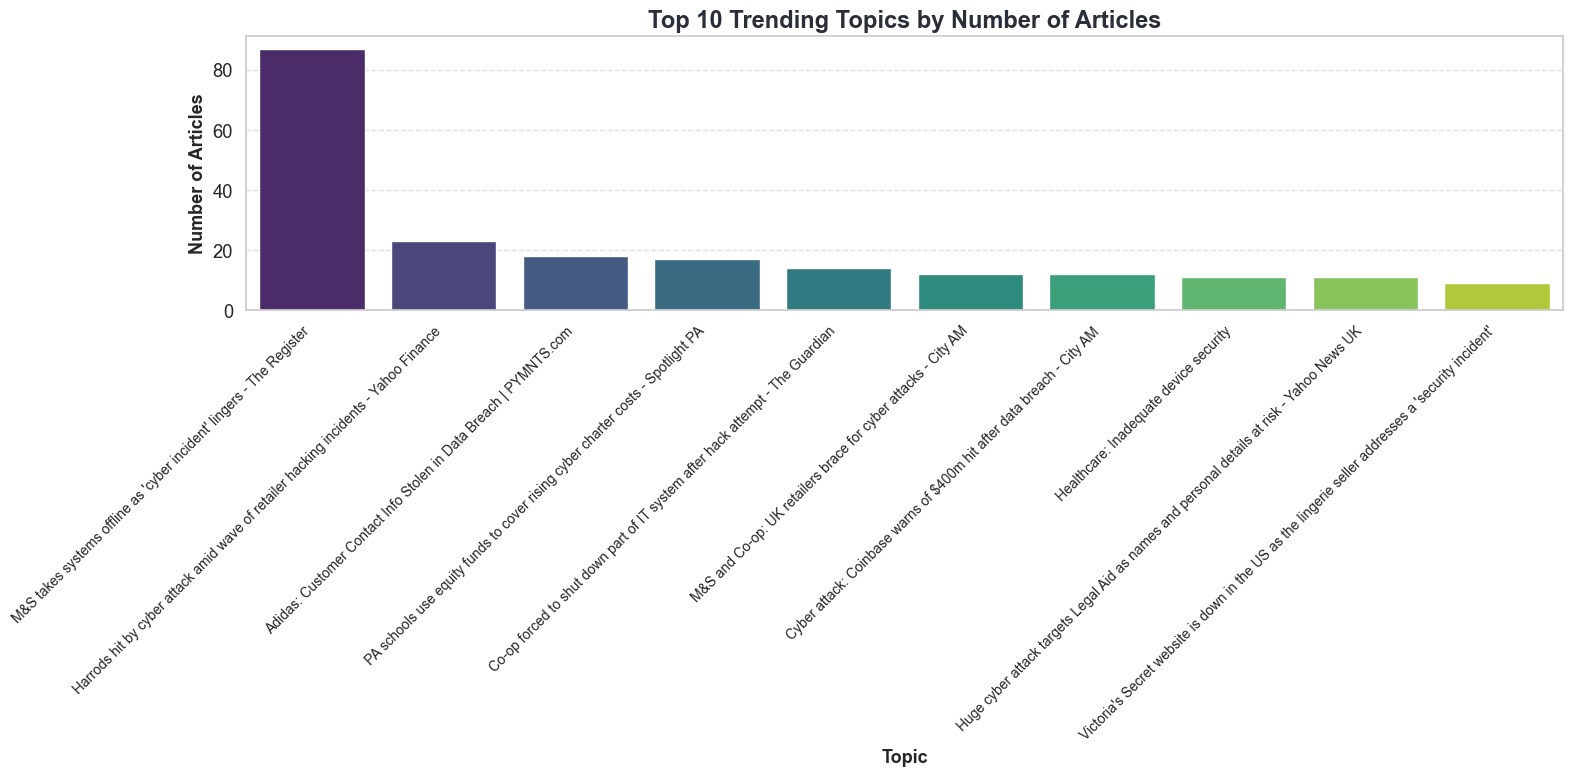

In [131]:
top_trends = trends_df.sort_values(['num_articles', 'num_days'], ascending=False).head(10 )
top_topic_ids = top_trends['topic_id'].tolist()
id_to_title = dict(zip(top_trends['topic_id'], top_trends['short_title']))

plt.figure(figsize=(16, 8))
sns.barplot(
    data=top_trends, 
    x='short_title',
    y='num_articles',
    hue='short_title',
    palette='viridis',
    legend=False
)
plt.title('Top 10 Trending Topics by Number of Articles', fontsize=17, fontweight='bold', color='#2a2e38')
plt.xlabel('Topic', fontsize=13, fontweight='bold')
plt.ylabel('Number of Articles', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)# plt.grid(axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### <div dir="rtl"> 🔸גרף 2: המחשת מגמות פרסום יומיות לנושאים החמים ביותר מחשבים את מספר המאמרים שפורסמו בכל יום עבור כל אחד מהנושאים החמים, משייכים צבע ייחודי לכל נושא, ובונים גרף קווים שבו כל קו מייצג נושא שונה. בנוסף, צובעים שטח מתחת לכל קו ומסמנים את נקודות השיא (כאשר פורסמו 10 מאמרים או יותר) כדי להדגיש דינמיקת פרסום לאורך זמן. </div> 

<div dir="rtl"> <strong>ניתוח הפלט:</strong> הגרף מדגים בצורה ברורה את מגמות הפרסום היומי של עשרת הנושאים החמים ביותר. רואים שלחלק מהנושאים יש "התפוצצות" פתאומית בכמות הפרסומים ביום מסוים (שיאים של 21–22 מאמרים ביום בודד), ואחריהם חזרה לרמות נמוכות הרבה יותר. נושאים אחרים מציגים דפוס יציב יחסית, ללא שיאים דרמטיים. הקווים הצבעוניים והשטחים המודגשים מתחת לכל קו מדגישים את העוצמה והרצף של כל נושא לאורך זמן. המשמעות: הגרף עוזר לזהות האם נושא מסוים קיבל תשומת לב פתאומית (ספייק), האם מדובר בעניין ממושך, והאם יש נושאים שזוכים לסיקור עקבי לעומת כאלה שמופיעים פתאום ונעלמים. בזכות כך, ניתן להעריך האם מדובר בטרנד חולף, באירוע חד-פעמי משמעותי, או במגמה מתמשכת בתחום הסייבר. </div>

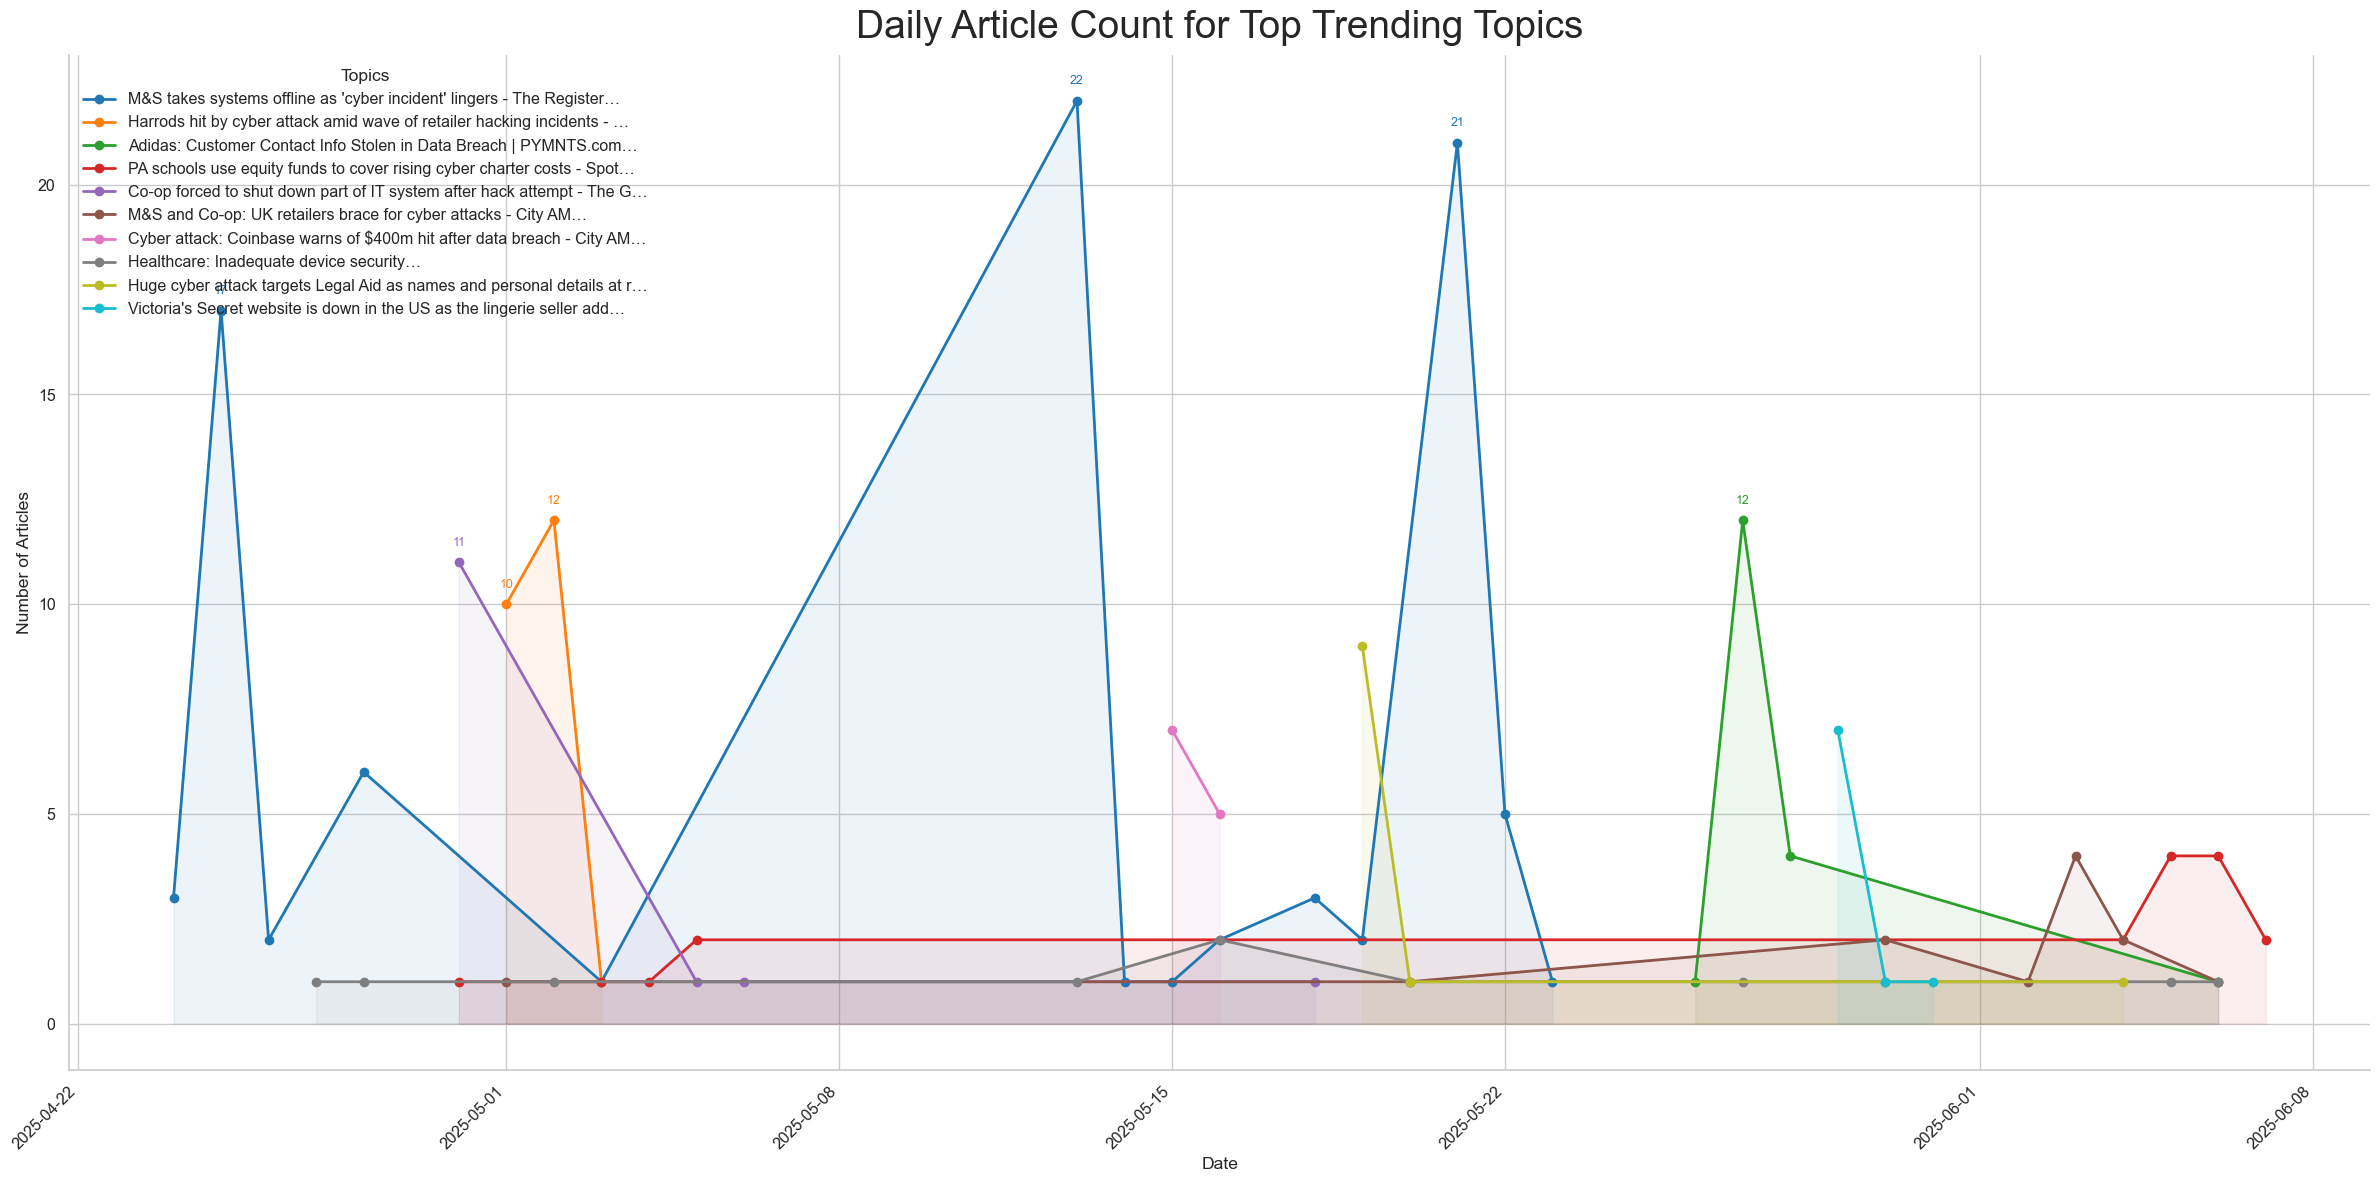

In [132]:

sns.set_theme(style="whitegrid", font_scale=1.05)
mask = topic_df['topic_id'].isin(top_topic_ids)
daily_counts = (topic_df.loc[mask]
                .groupby(['topic_id', 'published_date'])
                .size()
                .reset_index(name='count')
                .merge(topics_df[['topic_id', 'short_title']], on='topic_id'))

daily_counts = daily_counts.sort_values('published_date')


palette = sns.color_palette('tab10', n_colors=len(top_topic_ids))
colours = {tid: palette[i] for i, tid in enumerate(top_topic_ids)}


fig, ax = plt.subplots(figsize=(24, 12))

for tid in top_topic_ids:
    sub = daily_counts[daily_counts['topic_id'] == tid]

    ax.plot(sub['published_date'], sub['count'],
        marker='o', linewidth=2, color=colours[tid], label=sub['short_title'].iloc[0][:70] + '…')

    ax.fill_between(sub['published_date'],
                sub['count'], color=colours[tid], alpha=.08)

    for x, y in zip(sub['published_date'], sub['count']):
        if y >= 10:
            ax.text(x, y + 0.4, f'{y}', ha='center',
                    fontsize=9, color=colours[tid])

ax.set_title('Daily Article Count for Top Trending Topics', fontsize=28, pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Articles')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Topics', frameon=False, loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()


#### <div dir="rtl"> 🔸גרף 3: ענן מילים של מילות המפתח במגמות החמות מאחדים את כל מילות המפתח המרכזיות מתוך הנושאים החמים ביותר לטקסט אחד, ומייצרים ענן מילים (Word Cloud) שממחיש בצורה ויזואלית אילו מילות מפתח מופיעות הכי הרבה ומשפיעות על מגמות הסייבר העדכניות. </div>

<div dir="rtl"> <strong>ניתוח הפלט:</strong> ענן המילים מדגיש בבירור שמילות הליבה של מגמות הסייבר הן cyber, security, attack, ו-cybersecurity – כלומר, רוב הכתבות והאירועים עוסקים ישירות באבטחת מידע, מתקפות סייבר ותגובות לאיומים. ניתן לראות גם בולטים מושגים משניים כמו incident, ransomware, defense, information, health, group, ו-national, שמעידים על נושאים חוזרים: מתקפות כופרה, אירועים לאומיים, סוגיות בריאותיות, דליפות מידע ושחקנים בולטים בזירה. המשמעות: מיפוי מהיר של מושגי המפתח מסייע לזהות לא רק את מגמות הסייבר, אלא גם את סוגי האיומים, הענפים הנפגעים וההקשרים הרחבים (כמו ממשלות, בריאות, מגזר קמעונאי). גרף זה מהווה כלי יעיל לאנליסטים ולמנהלים להבין מיד מהם הנושאים החמים ומהיכן צומחות מגמות חדשות בשיח התקשורתי והמקצועי. </div>

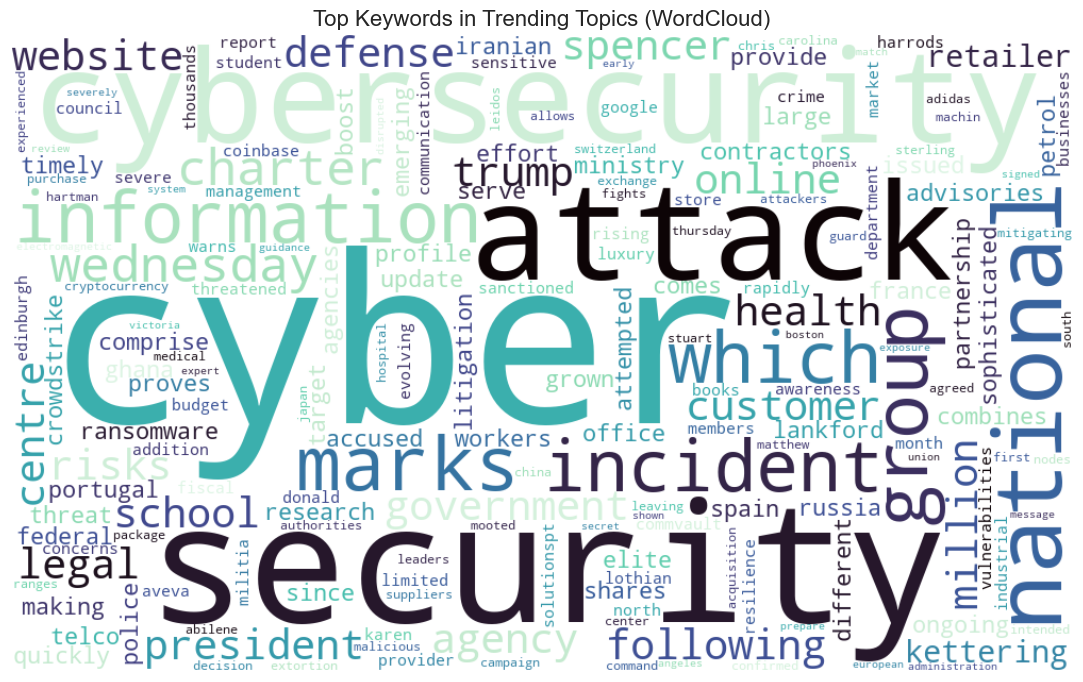

In [133]:
# לוקח את עמודת top_keywords מטבלת הטרנדים (trends_df 
trend_keywords_series = trends_df['top_keywords'].dropna().astype(str) # משמיד ערכים חסרים והופך כל ערך לחרוזת
text_blob = ' '.join(trend_keywords_series)# מאחד את כל מילות המפתח לקובץ טקסט אחד ארוך:

# יצרת אובייקט ענן מילים
wordcloud = WordCloud(width=1000, height=600, background_color='white', colormap='mako',contour_width=2,
    contour_color='steelblue',stopwords=stopwords).generate(text_blob)
# מציג את ענן המילים
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Keywords in Trending Topics (WordCloud)', fontsize=16)
plt.tight_layout()
plt.show()


#### <div dir="rtl"> 🔸גרף 4: המחשת 7 המגמות המובילות עם תקצירים מפורטים לשבעת הנושאים המרכזיים ביותר, עוטפים את תקציר המאמר המייצג, מפיקים את מילות המפתח המרכזיות, ומשרטטים תרשים עמודות אופקי של כמות המאמרים. כל עמודה מלווה בתיאור קצר שמציג את סוג המגמה, מספר הכתבות, ימי פעילות, היום הדומיננטי, המדינה ומילות המפתח – הכל במטרה לאפשר פרשנות מהירה וברורה. </div>

<div dir="rtl"> <strong>ניתוח הפלט:</strong> הגרף האופקי מציג בבירור את שבע מגמות הסייבר המובילות, כולל תקציר מפורט של כל מגמה ונתוני עומק בצמוד לכל עמודה. ניתן לראות מגמה אחת ששולטת באופן מובהק (87 מאמרים ב-14 ימים, שיא יומי של 22), העוסקת בפריצת סייבר לרשת קמעונאות – עם מילות מפתח חוזרות כמו spencer, cyber, attack, marks, online. שאר המגמות נמצאות הרחק מאחור – כל אחת מתאפיינת בשילוב אחר של נושאים: מתקפת סייבר על חברת אופנה, פרצת נתונים בענקית תשלומים, נושאי ביטחון לאומי, תשלומי כופר (ransomware) ועוד. לכל מגמה מוצגות אינפורמציה על מספר כתבות, ימי פעילות, יום שיא, מדינה דומיננטית ומילות מפתח – נתונים שמסייעים להבין במהירות את מאפייני כל מגמה ואת הדינמיקה שלה. המשמעות: גרף זה מאפשר זיהוי מידי של מגמות על פי נפח התקשורת, הבנה של הקשרים מרכזיים, והשוואה בין עוצמתן של תופעות סייבר שונות בשוק הגלובלי. </div>


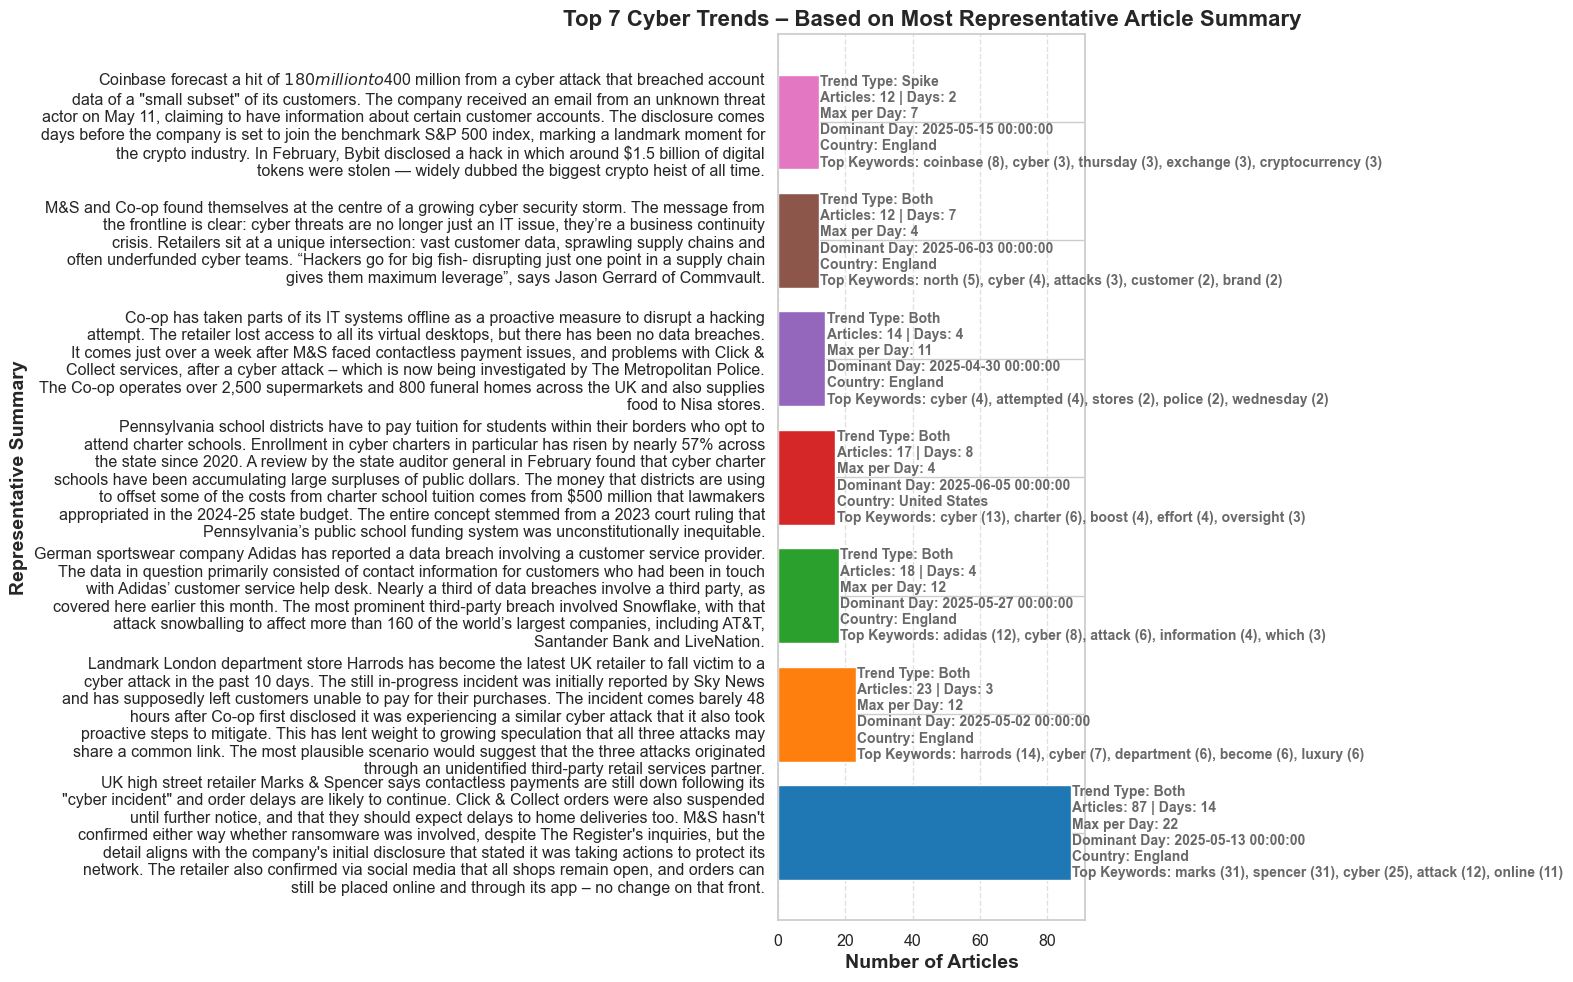

In [134]:
# מוצא את 7 הנושאים שהיו הכי בולטים ועקביים
top_topic_ids = trends_df.sort_values(['num_articles', 'num_days'], ascending=False).head(7)['topic_id']

# יוצר טבלה עם כל הכתבות של 7 הנושאים, ומוודא שמילות המפתח הן מחרוזת אחת לכל כתבה.
top_articles = articles_df[articles_df['topic_id'].isin(top_topic_ids)].copy()
if isinstance(top_articles['cleaned_keywords'].iloc[0], list):
    top_articles['cleaned_keywords'] = top_articles['cleaned_keywords'].apply(lambda x: ' '.join(x))

# מאחד את כל מילות המפתח של כל נושא
topic_keywords = top_articles.groupby('topic_id')['cleaned_keywords'].apply(lambda x: ' '.join(x))
vec = CountVectorizer() # בדיקה כמה פעמים הופיעה כל מילה בכל נושא
X = vec.fit_transform(topic_keywords)
keyword_matrix = pd.DataFrame(X.toarray(), index=topic_keywords.index, columns=vec.get_feature_names_out())

#פונקציה שמחזירה את 5 המילים הכי נפוצות לכל נושא, כולל כמות ההופעות של כל מילה
def get_top5_keywords(row):
    topic_id = row['topic_id']
    if topic_id in keyword_matrix.index:
        top_words = keyword_matrix.loc[topic_id].sort_values(ascending=False).head(5)
        top_words = top_words[top_words > 0]
        return ', '.join([f"{word} ({count})" for word, count in top_words.items()])
    else:
        return "N/A"

# פונקציה שמפרקת סיכום ארוך לשורות קצרות (לכותרת הגרף),
def wrap_summary(text, max_len=100, max_lines=7):
    words = text.split()
    lines = []
    line = ""
    for word in words:
        if len(line + " " + word) <= max_len:
            line += " " + word
        else:
            lines.append(line.strip())
            line = word
            if len(lines) == max_lines:
                break
    if line and len(lines) < max_lines:
        lines.append(line.strip())
    return '\n'.join(lines)

# הכנה להצגה — לכל טרנד:
top7 = trends_df[trends_df['topic_id'].isin(top_topic_ids)].sort_values(by=['num_articles', 'num_days'], ascending=False).copy()

# עמודת סיכום מקוצרת (wrapped_title)
top7['wrapped_title'] = top7['representative_summary'].apply(wrap_summary)
# 5 מילות מפתח הכי חזקות בטרנד
top7['top5_keywords'] = top7.apply(get_top5_keywords, axis=1)

# יצירת תווית הסבר לכל בר
top7['label'] = top7.apply(lambda row: (
    f"Trend Type: {row['trend_type']}\n"
    f"Articles: {row['num_articles']} | Days: {row['num_days']}\n"
    f"Max per Day: {row['max_articles_per_day']}\n"
    f"Dominant Day: {row['dominant_day']}\n"
    f"Country: {row['main_country']}\n"
    f"Top Keywords: {row['top5_keywords']}"
), axis=1)

#מכין גרף ברים אופקי:
colors = plt.cm.tab10.colors
bar_colors = [colors[i % len(colors)] for i in range(len(top7))]

fig, ax = plt.subplots(figsize=(16, 10))
bars = ax.barh(top7['wrapped_title'], top7['num_articles'], color=bar_colors)

# מציב ליד כל בר את תווית ההסבר עם כל המידע החשוב על אותו טרנד.
for bar, label in zip(bars, top7['label']):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        label,
        va='center',
        ha='left',
        fontsize=10,
        color='dimgray'
        , fontweight='bold'
    )

# כותרות, עיצוב, רשת, תצוגה מסודרת — ומציג את הגרף.
ax.set_title("Top 7 Cyber Trends – Based on Most Representative Article Summary", fontsize=16, fontweight='bold')
ax.set_xlabel("Number of Articles", fontsize=14, fontweight='bold')
ax.set_ylabel("Representative Summary", fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout(rect=[0, 0, 0.97, 1]) 
plt.show()



